# Options

This notebook provides a structured introduction to options and demonstrates how options strategies can be incorporated into quantitative portfolio construction, risk management, and return enhancement frameworks. We will be delving into the basics of Options, before moving on to talk about some common options strategies. The following section outlines the concepts that will be covered in this notebook.

- Option Payoffs vs Profit/Loss
- Basic Option Payoffs and Profit/Loss
- Common Option Strategies
  - Bear $Put$ Spread
  - Bull $Call$ Spread
  - Covered $Call$
  - Protective $Put$
  - Long Straddle
  - Long Strangle
  - Short Straddle
  - Short Strangle
  - Iron Condor
  - Long Butterfly Spread / $Call$ Fly
  - Short Butterfly Spread / $Put$ Fly 
- Black-Scholes Option Pricing Model
- Option Greeks

**Note**: When we use **long** and **short** options in this notebook, we meant **buying** and **selling** the options respectively.

Import the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import warnings
import pandas_datareader as pdr
import plotly.graph_objects as go
import math
from scipy.stats import norm

warnings.filterwarnings("ignore")

### 1. Option Payoffs vs Profit/Loss

In options trading, it is important to distinguish between the **payoff** of an option and its **profit or loss (P&L)**. The **payoff** refers to the value of the option at expiration and depends only on the terminal underlying price $S_t$ and the strike price $K$, without considering any cost incurred. For example, the payoff of a long call option is given by $\max(S_t - K, 0)$, while the payoff of a long put option is $\max(K - S_t, 0)$. In contrast, **profit or loss (P&L)** represents the actual financial outcome of the trade and accounts for the premium paid (or received) when entering the position. It is therefore defined as

$$
\text{P\&L} = \text{Payoff} - \text{Premium}
$$

For a long call, this becomes $\max(S_T - K, 0) - C$, where $C$ is the call premium, and for a long put, $\max(K - S_T, 0) - P$, where $P$ is the put premium. This distinction implies that while payoff diagrams always start at zero or above for long options, P&L diagrams are shifted downward by the premium, often resulting in losses unless the option finishes sufficiently in-the-money. In essence, the payoff captures the structural value of the option at expiry, whereas $P\&L$ reflects the true economic gain or loss from the trade.


### 2. Basic Option (Call  $Put$) Payoff and Profit/Loss

This section explores the basic payoff structure for buying or selling either a call or $Put$. This will lay the foundation for subsequent strategies and complex payoffs involving many options.

#### $Put$ Payoff

```put_payoff()``` is a function that calculates the payoff from buying or selling **a** $Put$. The function takes $s_t$ which is a range of possible values of the underlying price at expiration and the strike price of the $Put$ option. It then returns the $Put$ option payoff. 

Recall that:
- When the underlying price $s_t$ is less than the strike price at expiration, the $Put$ option is in the money and the payoff is the difference (i.e $\text{Strike Price} - s_t$)
- When the underlying price $s_t$ is greater than the strike price at expiration, the $Put$ option expires worthless

In [2]:
def put_payoff(sT, strike_price, action="long"): # Action can be "long" or "short", which means buying or selling the put option, respectively.
  if action == "long":
    # Buying put meaans that you will make a profit if the underlying price goes down, and you will lose money if the underlying price goes up.
    # The payoff is the difference between the strike price and the underlying price at maturity
    return np.where(sT < strike_price, strike_price - sT, 0)
  elif action == "short":
    # Selling put means that you will make a profit if the underlying price goes up, and you will lose money if the underlying price goes down.
    # The payoff is the difference between the underlying price and the strike price at maturity
    return np.where(sT < strike_price, sT - strike_price, 0)

#### $Call$ Payoff

```call_payoff()``` is a function that calculates the payoff from buying a $Call$ option. The function takes $s_t$ which is a range of possible values of the underlying price at expiration and the strike price of the $Call$ option. It returns the $Call$ option payoff.

Recall that:
- When the underlying price $s_t$ is greater than the strike price at expiration, the $Call$ option is in the money and the payoff is the difference (i.e $S_t - \text{Strike Price}$)
- When the underlying price $s_t$ is less than the strike price at expiration, the $Call$ option expires worthless

In [3]:
def call_payoff(sT, strike_price, action="long"): # Action can be "long" or "short", which means buying or selling the call option, respectively.
  if action == "long":
    # Buying call means that you will make a profit if the underlying price goes up, and you will lose money if the underlying price goes down.
    # The payoff is the difference between the underlying price and the strike price at maturity
    return np.where(sT > strike_price, sT - strike_price, 0)
  elif action == "short":
    # Selling call means that you will make a profit if the underlying price goes down, and you will lose money if the underlying price goes up.
    # The payoff is the difference between the strike price and the underlying price at maturity 
    return np.where(sT > strike_price, strike_price - sT, 0)

We will define a $\text{Profit and Loss}$ plot for the ease of visualising the final $PnL$ of the options once premium is factored into the payoffs.

In [4]:
def payoff_profit_loss_plot(sT, payoffs, premium, label_info, action, title, line_colour='g'):
  if action == "long":
    pnl = payoffs - premium
  elif action == "short":
    pnl = payoffs + premium
  fig, ax = plt.subplots(figsize=(18, 5))
  # Plot the payoff curve
  ax.plot(sT, payoffs, label=f"Payoff for {label_info}", color='grey', linestyle='-', alpha=0.3)
  # Plot the profit/loss curve
  breakeven_points = sT[np.isclose(pnl, 0, atol=0.5)]
  for be in breakeven_points: 
    ax.plot(sT, pnl, label=f"Strategy PnL | Premium = {premium:.2f} | Breakeven = {be}", color=line_colour)
  # Shade PROFIT region (green)
  ax.fill_between(sT, pnl, 0, where=(pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region')
  # Shade LOSS region (red)
  ax.fill_between(sT, pnl, 0, where=(pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region')
  # Bold the zero line
  ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
  
  plt.xlabel('XYZ Underlying Price')
  plt.ylabel('Profit / Loss')
  plt.grid()
  plt.title(title)
  plt.legend()
  plt.show()

#### $Put$ Payoff and Proft/Loss Example

Let us visualise the $Put$ Payoff and PnL diagram with the following information
- **Long** a $Put$ with $\text{Strike Price} = {\$880}$
- **Short** a $Put$ with $\text{Strike Price} = {\$860}$
- $\text{Spot Price} = {\$900}$
- Premium paid for the **Long** $Put$ is $\$15$
- Premium received for the **Short** $Put$ is $\$10$

In [5]:
spot_price = 900 

# Long Put
strike_price_long_Put = 880 
premium_long_Put = 15

# Short Put
strike_price_short_Put = 860 
premium_short_Put = 10

# underlying price range at expiration of the Put
sT = np.arange(0.9*spot_price,1.05*spot_price,1) 

**Long 880 Strike $Put$ Payoff and Profit/Loss**

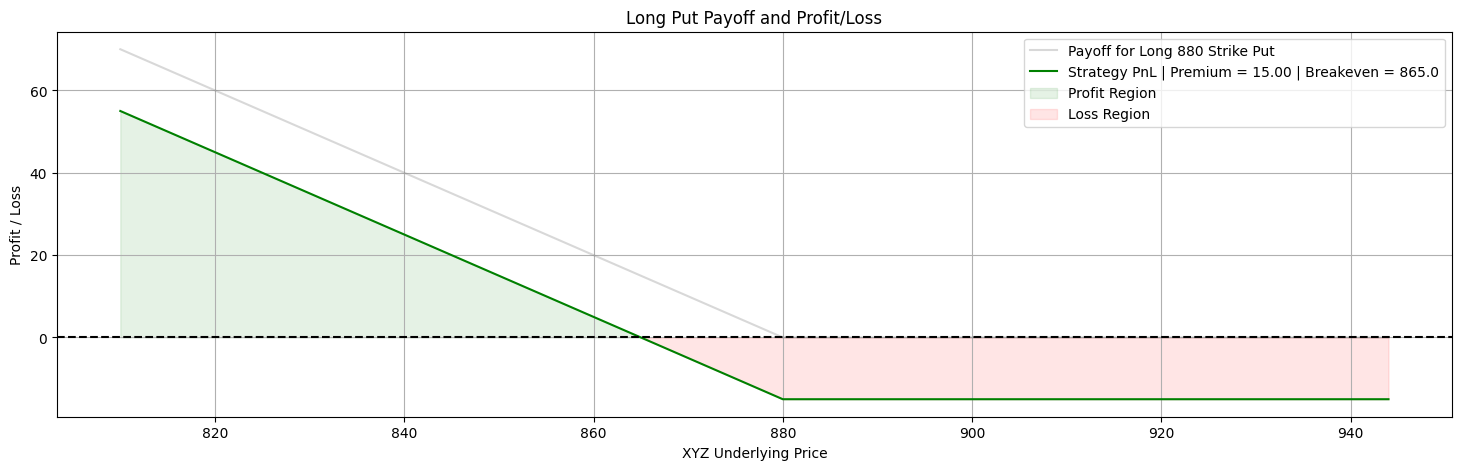

In [6]:
payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
payoff_profit_loss_plot(sT, payoff_long_Put, premium_long_Put, action='long', label_info='Long 880 Strike Put', title='Long Put Payoff and Profit/Loss')

**Short 860 Strike $Put$ Payoff and Profit/Loss**

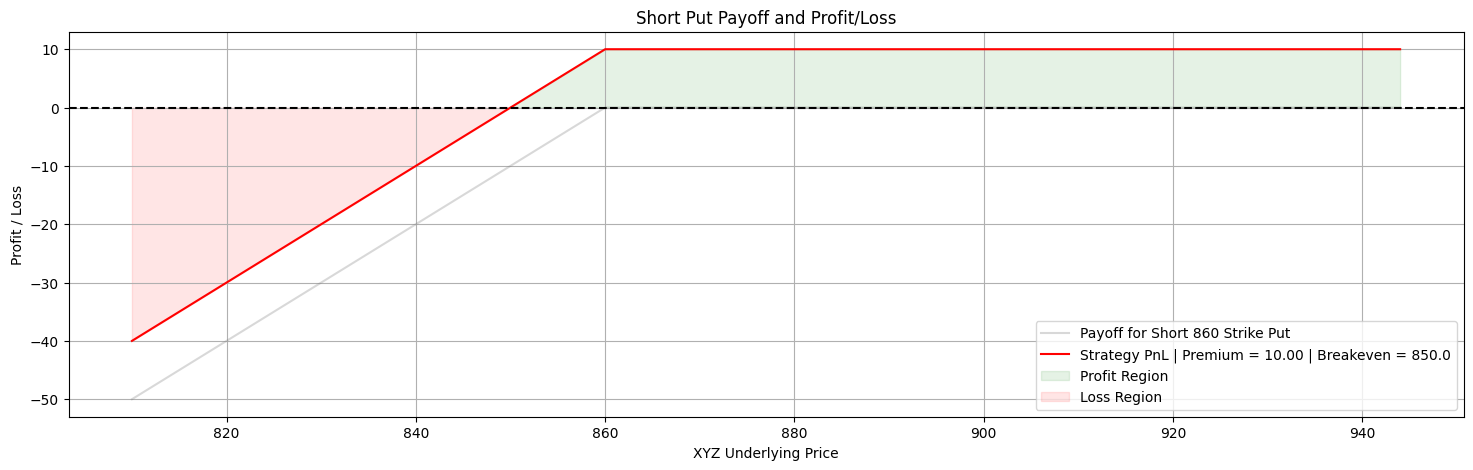

In [7]:
payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
payoff_profit_loss_plot(sT, payoff_short_Put, premium_short_Put, action="short", label_info="Short 860 Strike Put", title="Short Put Payoff and Profit/Loss", line_colour="r")

#### $Call$ Payoff and Proft/Loss Example

Let us visualise the Call Payoff with the following information
- **Long** a $Call$ with $\text{Strike Price} = {\$920}$
- **Short** a $Call$ with $\text{Strike Price} = {\$940}$
- $\text{Spot Price} = {\$900}$
- Premium paid for the **Long** $Call$ is $\$15$
- Premium received for the **Short** $Call$ is $\$10$

In [8]:
spot_price = 900

# Long call
strike_price_long_call = 920
premium_long_call = 15

# Short call
strike_price_short_call = 940
premium_short_call = 10

# underlying price range at expiration of the call
sT = np.arange(0.95*spot_price, 1.1*spot_price, 1)

**Long 920 Strike Call Payoff and Profit/Loss**

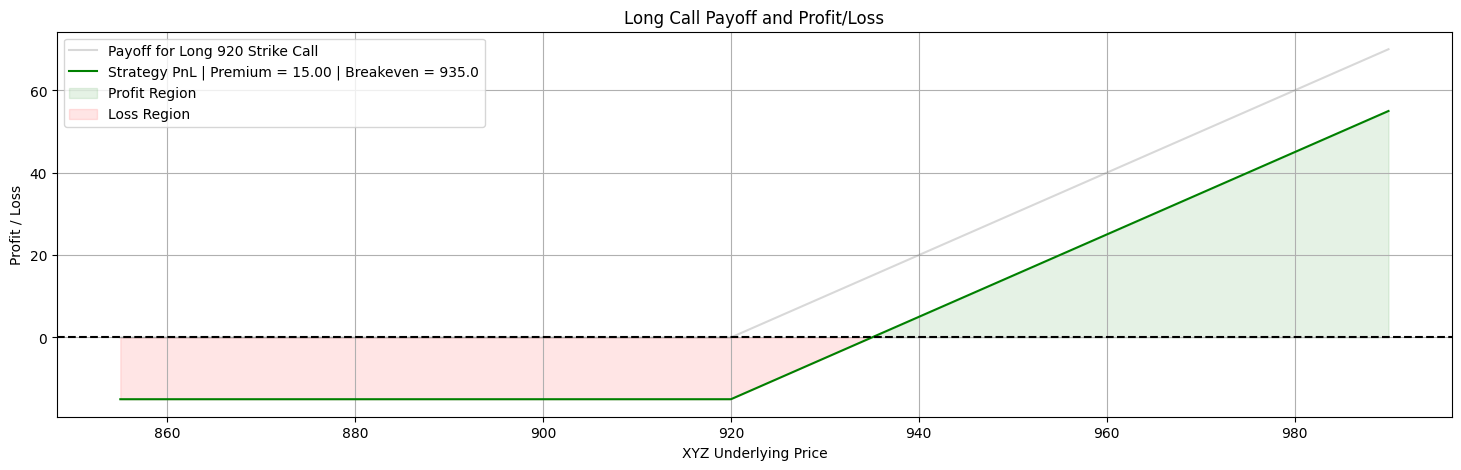

In [9]:
payoff_long_call = call_payoff(sT, strike_price_long_call, action="long")
payoff_profit_loss_plot(sT, payoff_long_call, premium_long_call, action='long', label_info='Long 920 Strike Call', title='Long Call Payoff and Profit/Loss')

**Short 940 Strike Call Payoff and Profit/Loss**

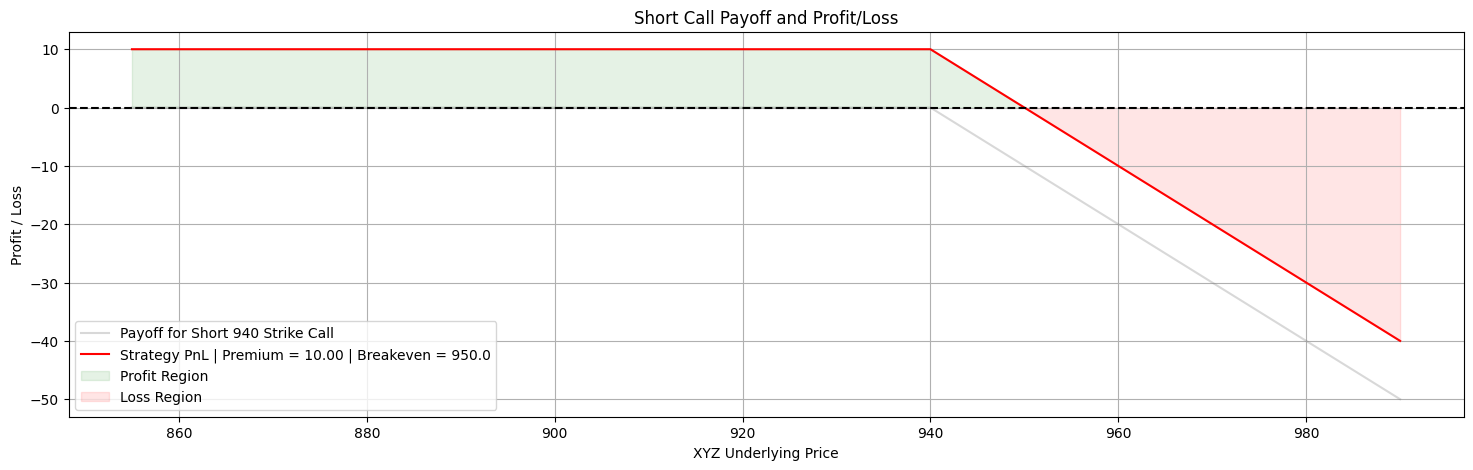

In [10]:
payoff_short_call = call_payoff(sT, strike_price_short_call, action="short")
payoff_profit_loss_plot(sT, payoff_short_call, premium_short_call, action = 'short', label_info='Short 940 Strike Call', title='Short Call Payoff and Profit/Loss', line_colour='r')

#### Combining all 4 different basic Payoff and PnL Charts

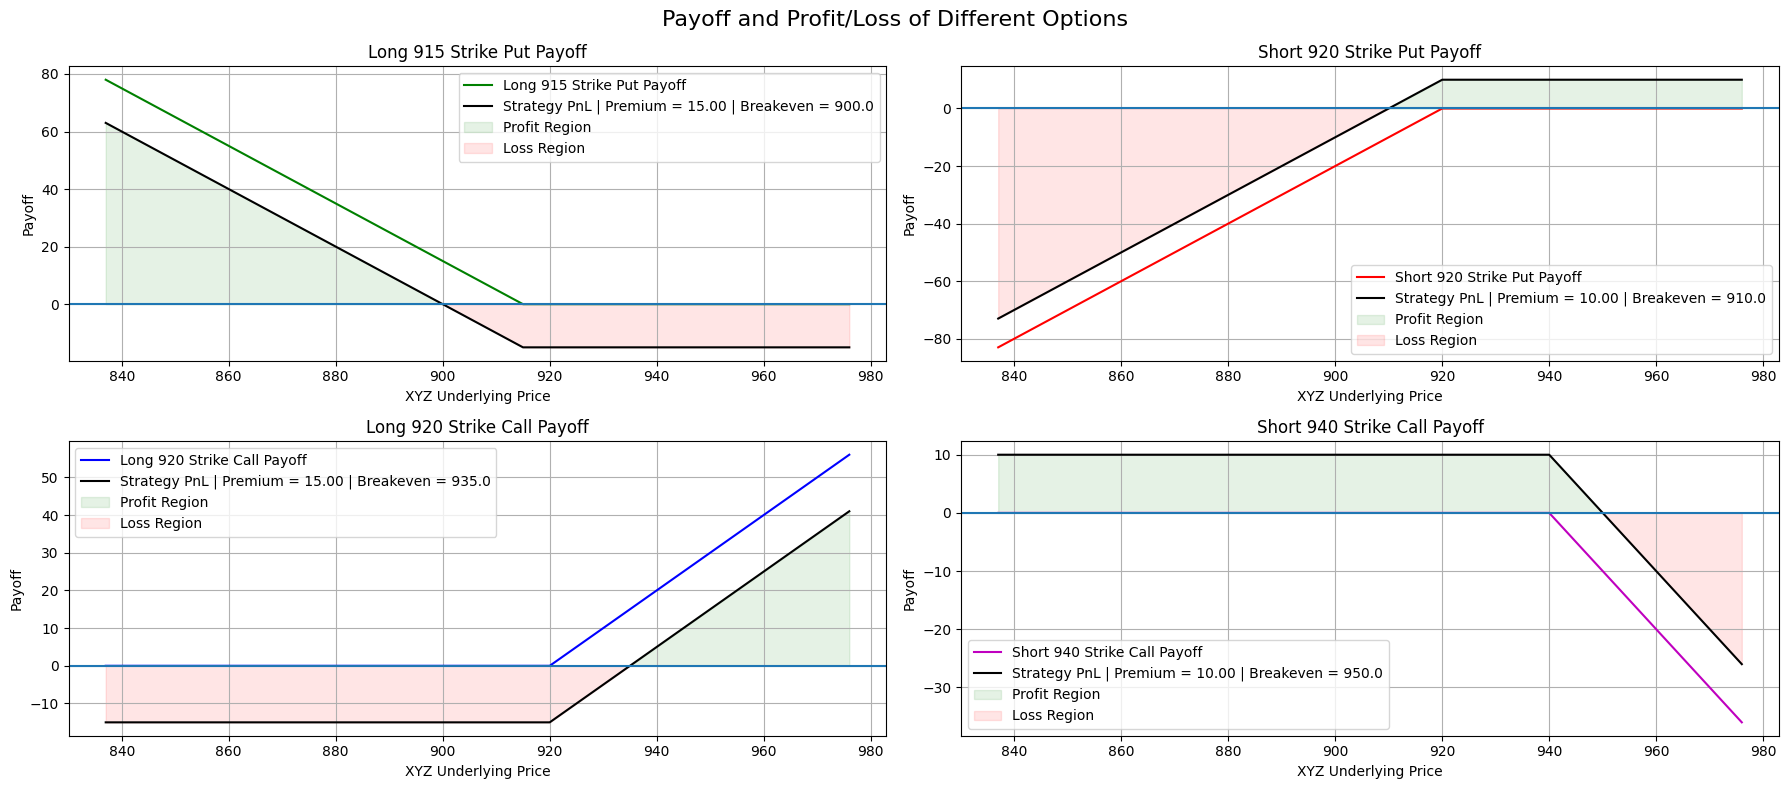

In [11]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_long_Put = 915 
premium_long_Put = 15
strike_price_short_Put = 920 
premium_short_Put = 10
strike_price_long_call = 920
premium_long_call = 15
strike_price_short_call = 940
premium_short_call = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

payoff_list = []
premium_list = [premium_long_Put, premium_short_Put, premium_long_call, premium_short_call]
payoff_list.append(put_payoff(sT, strike_price_long_Put, action="long"))
payoff_list.append(put_payoff(sT, strike_price_short_Put, action="short"))
payoff_list.append(call_payoff(sT, strike_price_long_call, action="long"))
payoff_list.append(call_payoff(sT, strike_price_short_call, action="short"))

label_list = ['Long 915 Strike Put Payoff', 'Short 920 Strike Put Payoff', 'Long 920 Strike Call Payoff', 'Short 940 Strike Call Payoff']
action = ["long", "short", "long", "short"]
colour_list = ['g', 'r', 'b', 'm']

# Plot them in 4 different quadrants with different colours and labels
fig, axs = plt.subplots(2, 2, figsize=(18, 8))
axs = axs.flatten()
for i, (payoff, premium, action, label, colour_code) in enumerate(zip(payoff_list, premium_list, action, label_list, colour_list)):
  axs[i].plot(sT, payoff, label=label, color=colour_code)
    
  # Compute PnL
  pnl = payoff - premium if action == "long" else payoff + premium

  # Plot the profit/loss curve
  breakeven_points = sT[np.isclose(pnl, 0, atol=0.5)]
  for be in breakeven_points: 
    axs[i].plot(sT, pnl, label=f"Strategy PnL | Premium = {premium:.2f} | Breakeven = {be}", color='black')
  axs[i].axhline(0)  # x-axis at zero payoff
  axs[i].fill_between(sT, pnl, 0, where=(pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region')
  axs[i].fill_between(sT, pnl, 0, where=(pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region')
  axs[i].set_title(label_list[i])
  axs[i].set_xlabel('XYZ Underlying Price')
  axs[i].set_ylabel('Payoff')
  axs[i].grid()
  axs[i].legend()
plt.suptitle('Payoff and Profit/Loss of Different Options', fontsize=16)
plt.tight_layout()
plt.show()

### 2. Common Option Strategies

#### Option Strategy 1: Bear $Put$ Spread

A Bear $Put$ Spread is a bearish options strategy that involves buying a $Put$ option at a higher $\text{Strike Price}$ and simultaneously selling another $Put$ option at a lower $\text{Strike Price}$. This structure reduces the net premium paid compared to a single long $Put$ while limiting both the maximum profit and maximum loss. The strategy benefits from a moderate decline in the underlying asset’s price before expiration. Looking at our long and short $Put$, our bear $Put$ spread payoff formula is simply:

$$
\text{Bear Put Spread (Payoff)} = \text{Long Put (Payoff)}_{\text{(Higher Strike)}} + \text{Short Put (Payoff)}_{\text{(Lower Strike)}} 
$$

Consider the following example Bear $Put$ Spread Strategy where we:
- **Long** a $Put$ with $\text{Strike Price} = {\$930}$
- **Short** a $Put$ with $\text{Strike Price} = {\$900}$
- $\text{Spot Price} = {\$930}$
- Premium paid for the **Long** $Put$ is $\$15$
- Premium received for the **Short** $Put$ is $\$10$

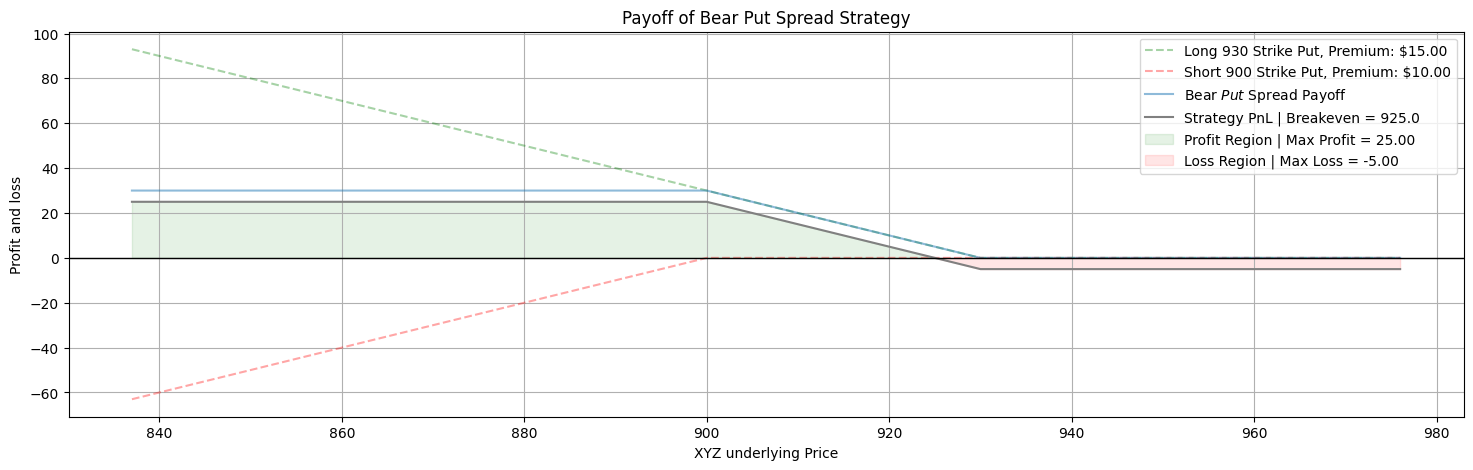

In [12]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_long_Put = 930
premium_long_Put = 15
strike_price_short_Put = 900 
premium_short_Put = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Individual payoff of the long and short Put
payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")

# Combined payoff of the long and short Put, which is the payoff of the bear Put spread strategy
payoff_bear_Put_spread = payoff_long_Put + payoff_short_Put

# Since we are long the long Put and short the short Put, we need to subtract the net premium paid (premium_long_Put - premium_short_Put)
# from the combined payoff to get the profit/loss of the bear Put spread strategy.
pnl_bear_Put_spread = payoff_bear_Put_spread - (premium_long_Put - premium_short_Put) 

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,payoff_long_Put,'--',label=f'Long 930 Strike Put, Premium: ${premium_long_Put:.2f}',color='g', alpha=0.35)
ax.plot(sT,payoff_short_Put,'--',label=f'Short 900 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,payoff_bear_Put_spread,label='Bear $Put$ Spread Payoff', alpha=0.5)

# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_bear_Put_spread, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_bear_Put_spread, label=f"Strategy PnL | Breakeven = {be}", color='grey')

# Profit region
ax.fill_between(sT, pnl_bear_Put_spread, 0, where=(pnl_bear_Put_spread > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(pnl_bear_Put_spread.max()))
ax.fill_between(sT, pnl_bear_Put_spread, 0, where=(pnl_bear_Put_spread < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(pnl_bear_Put_spread.min()))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Bear Put Spread Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

The max profit is capped at $15 and the max loss is limited to $5. Therefore, this strategy is suitable when your outlook is moderately bearish on the underlying. 

#### Option Strategy 2: Bull $Call$ Spread

A Bull $Call$ Spread is built by going long on $Call$ option and simultaneously selling a higher $\text{Strike Price}$ $Call$ option. This strategy aims to benefit from small positive movements in the underlying, and is suitable when your outlook is moderately bullish on the underlying. 

Looking at our long and short $Call$, our Bull $Call$ Spread payoff formula is simply:

$$
\text{Bull Call Spread (Payoff)} = \text{Long Call (Payoff)}_{\text{(Lower Strike)}} + \text{Short Call (Payoff)}_{\text{(Higher Strike)}} 
$$

Consider the following example Bull $Call$ Spread Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$930}$
- **Short** a $Call$ with $\text{Strike Price} = {\$950}$
- $\text{Spot Price} = {\$930}$
- Premium paid for the **Long** $Call$ is $\$15$
- Premium received for the **Short** $Call$ is $\$10$

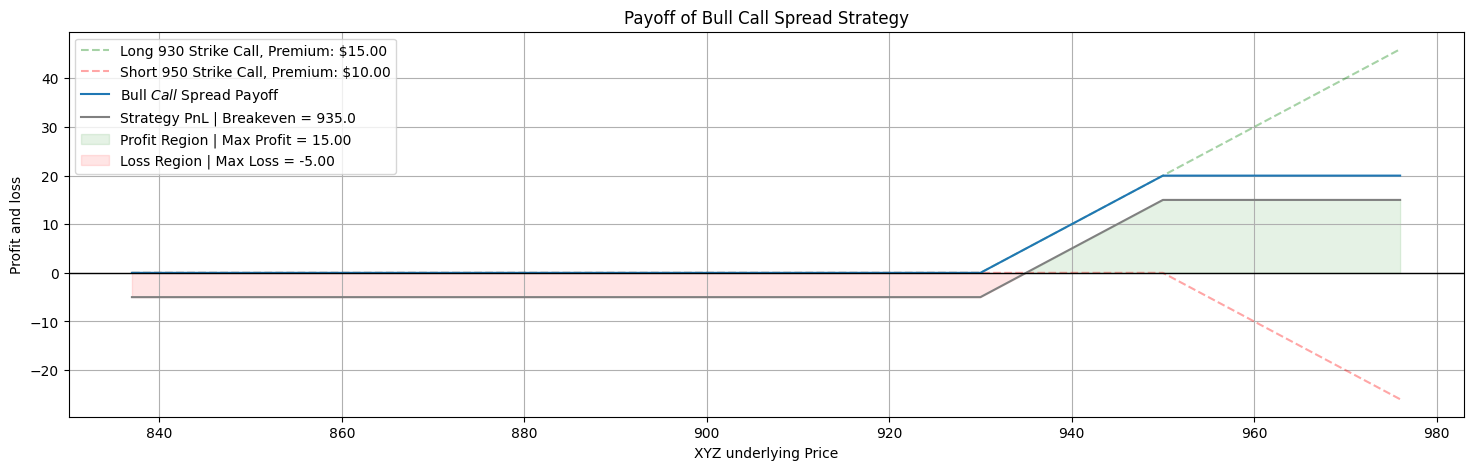

In [13]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_long_Call = 930
premium_long_Call = 15
strike_price_short_Call = 950 
premium_short_Call = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")
payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Combined payoff of the long and short Call, which is the payoff of the bull Call spread strategy
payoff_bull_call_spread = payoff_long_Call + payoff_short_Call
pnl_bull_call_spread = payoff_bull_call_spread - (premium_long_Call - premium_short_Call)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,payoff_long_Call,'--',label=f'Long 930 Strike Call, Premium: ${premium_long_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,payoff_short_Call,'--',label=f'Short 950 Strike Call, Premium: ${premium_short_Call:.2f}',color='r', alpha=0.35)
ax.plot(sT,payoff_bull_call_spread,label='Bull $Call$ Spread Payoff')

# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_bull_call_spread, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_bull_call_spread, label=f"Strategy PnL | Breakeven = {be}", color='grey')
  
# Profit region
ax.fill_between(sT, pnl_bull_call_spread, 0, where=(pnl_bull_call_spread > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(pnl_bull_call_spread.max()))
ax.fill_between(sT, pnl_bull_call_spread, 0, where=(pnl_bull_call_spread < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(pnl_bull_call_spread.min()))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Bull Call Spread Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Options Strategy 3: Covered Call

A Covered Call is an income-generating strategy that involves holding a long position in an underlying asset while simultaneously selling a $Call$ option on that same asset. The premium received from selling the $Call$ provides immediate income and offers partial downside protection. However, the upside potential is capped at the $Call$'s $\text{Strike Price}$ if the asset appreciates significantly.

$$
\text{Payoff} = 
\begin{cases} 
S_T - S_0 + C & \text{if } S_T \leq K \quad \text{(call expires worthless)} \\[1.2em]
K - S_0 + C   & \text{if } S_T > K \quad \text{(call is exercised)}
\end{cases}
$$

As for the profits and loss, they can be formulated as such:

$$
\text{Profit} = (S_T - S_0) + C - \max(S_T - K, 0)
$$

Consider the following example Covered $Call$ Strategy where we:
- **Long** the underlying at $\$930$
- **Short** a $Call$ with $\text{Strike Price} = {\$950}$
- Premium received for the **Short** $Call$ is $\$10$

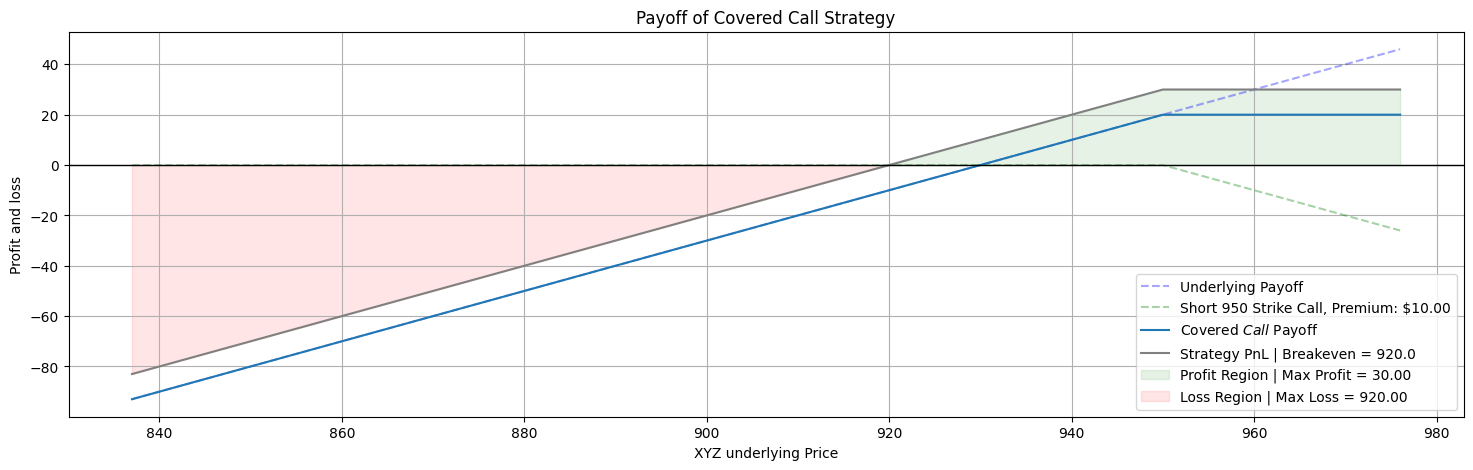

In [14]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 930
strike_price_short_Call = 950 
premium_short_Call = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Buy and hold the underlying
xyz_payoff = sT - spot_price

# Short Call Option payoff
xyz_payoff_short_call = call_payoff(sT, strike_price_short_Call, action="short")

# Covered Call Option Payoff
xyz_covered_call_payoff = xyz_payoff + xyz_payoff_short_call
pnl_covered_call = xyz_covered_call_payoff + premium_short_Call  # Since we are short the call, we receive the premium, so we add it to the payoff to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff,'--',label=f'Underlying Payoff',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_short_call,'--',label=f'Short 950 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_covered_call_payoff,label='Covered $Call$ Payoff')
  
# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_covered_call, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_covered_call, label=f"Strategy PnL | Breakeven = {be}", color='grey')
  
# Profit region
ax.fill_between(sT, pnl_covered_call, 0, where=(pnl_covered_call > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(pnl_covered_call.max()))
ax.fill_between(sT, pnl_covered_call, 0, where=(pnl_covered_call < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(spot_price - premium_short_Call))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Covered Call Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 4: Protective $Put$

A Protective $Put$ is a risk-management strategy that involves holding a long position in an underlying asset while purchasing a $Put$ option on the same asset. The $Put$ acts as insurance, providing downside protection by setting a minimum exit price. While the strategy preserves unlimited upside potential, the cost of the $Put$ reduces overall returns. The strategy payoff can be expressed as follow:

$$
\text{Payoff} = 
\begin{cases} 
S_T - S_0 - P & \text{if } S_T \geq K \quad \text{(put expires worthless)} \\[1.2em]
K - S_0 - P   & \text{if } S_T < K \quad \text{(put is exercised)}
\end{cases}
$$

As for the profit and loss, it can be defined as follow:

$$
\text{Profit} = 
\begin{cases} 
S_T - S_0 - P & \text{when } S_T \geq K \\[1.2em]
K - S_0 - P   & \text{when } S_T < K
\end{cases}
$$

Consider the following example Protective $Put$ Strategy where we:
- **Long** the underlying at $\$900$
- **Long** a $Put$ with $\text{Strike Price} = {\$880}$
- Premium paid for the **Long** $Put$ is $\$15$

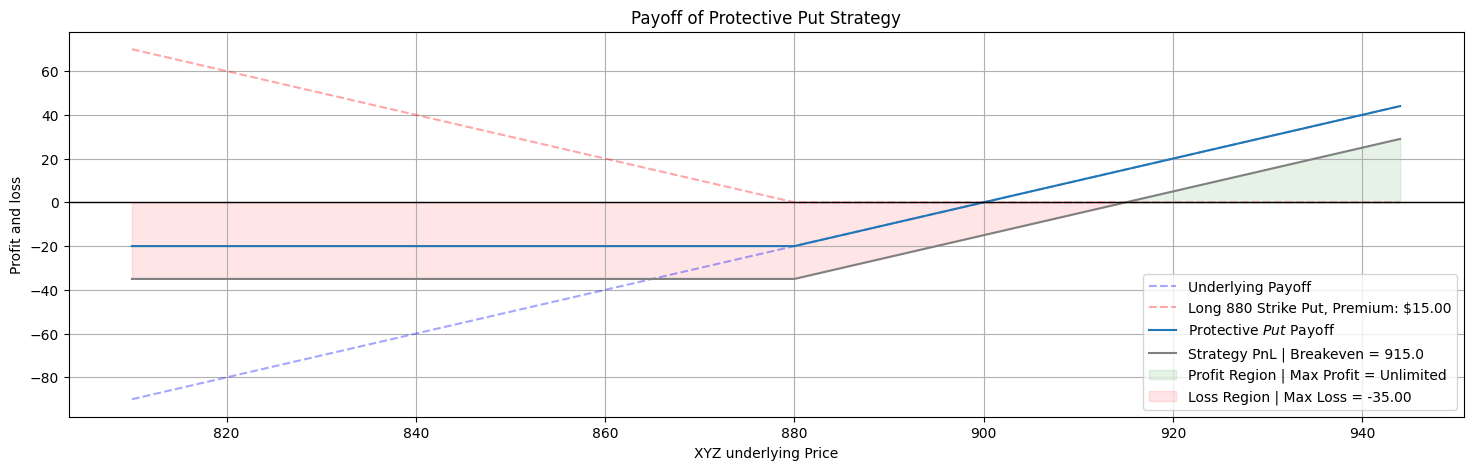

In [15]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 900
strike_price_long_Put = 880
premium_long_Put = 15

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Buy and hold the underlying
xyz_payoff = sT - spot_price

# Long Put Option payoff
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")

# Protective Put payoff and PnL
xyz_protective_Put_payoff = xyz_payoff + xyz_payoff_long_Put
pnl_protective_Put = xyz_protective_Put_payoff - premium_long_Put  # Since we are long the put, we need to subtract the premium paid to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff,'--',label=f'Underlying Payoff',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 880 Strike Put, Premium: ${premium_long_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_protective_Put_payoff,label='Protective $Put$ Payoff')
  
# Plot the profit/loss curve
breakeven_points = sT[np.isclose(pnl_protective_Put, 0, atol=0.5)]
for be in breakeven_points: 
  ax.plot(sT, pnl_protective_Put, label=f"Strategy PnL | Breakeven = {be}", color='grey')
  
# Profit region
ax.fill_between(sT, pnl_protective_Put, 0, where=(pnl_protective_Put > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = Unlimited')
ax.fill_between(sT, pnl_protective_Put, 0, where=(pnl_protective_Put < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(pnl_protective_Put)))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Protective Put Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 5: Long Straddle

A **Long Straddle** is an options strategy that involves going Long a $Call$ and Long a $Put$ of the same underlying, with the same $\text{Strike Price}$ (usually ATM) and same expiration date  

This is a **pure volatility play**: You profit from a **large move in either direction** (up or down), but lose if the stock stays relatively flat. It is often used before expected high-volatility events (earnings, FDA decisions, macro news, etc.).

**Profit Formula at Expiration**

The profit is simply the sum of the long call profit + long put profit:

$$
\text{Profit} = \max(S_T - K, 0) - C + \max(K - S_T, 0) - P
$$

Which simplifies to:

$$
\text{Profit} = \max(S_T - K, K - S_T) - T
$$

or equivalently:

$$
\text{Profit} = |S_T - K| - (C + P)
$$

- You make money when the absolute move $|S_T - K|$ > total premium paid.
- Maximum loss occurs when $S_T = K$ (both options expire worthless).

Consider the following example Long Straddle Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$880}$
- **Long** a $Put$ with $\text{Strike Price} = {\$880}$
- Premium paid for the **Long** $Call$ is $\$15$
- Premium paid for the **Long** $Put$ is $\$10$

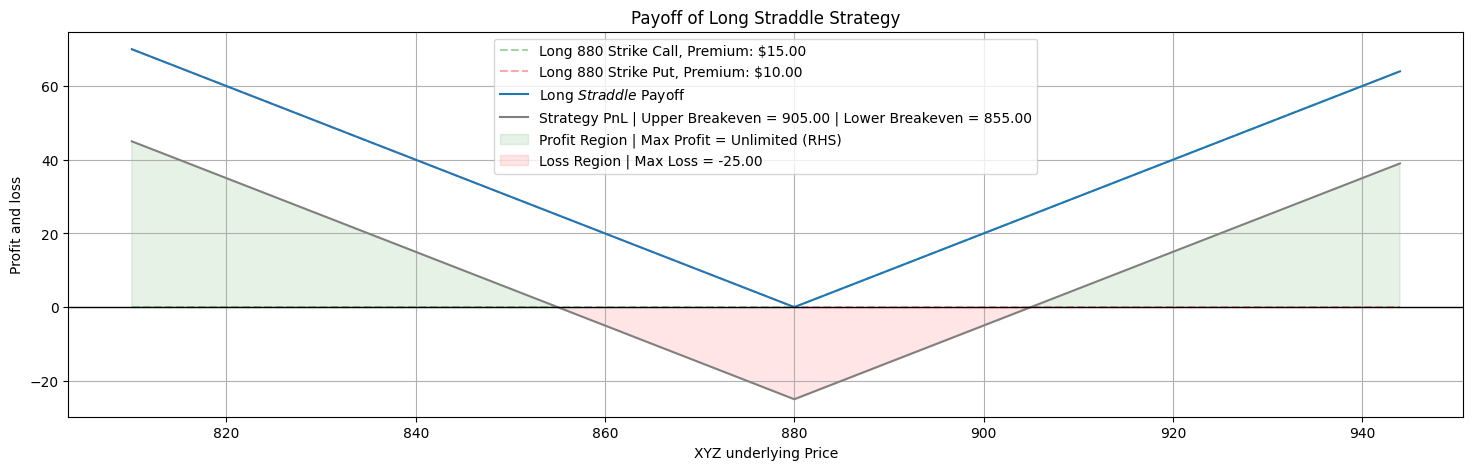

In [16]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 900
strike_price_long_Call = 880
premium_long_Call = 15
strike_price_long_Put = 880
premium_long_Put = 10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.05*spot_price,1)

# Long Put Option payoff
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
xyz_payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")

# Long Straddle payoff and PnL
xyz_long_Straddle_payoff = xyz_payoff_long_Call + xyz_payoff_long_Put
xyz_long_Straddle_pnl = xyz_long_Straddle_payoff - (premium_long_Call + premium_long_Put)  # Since we are long both the call and the put, we need to subtract the total premium paid to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_long_Call,'--',label=f'Long 880 Strike Call, Premium: ${premium_long_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 880 Strike Put, Premium: ${premium_long_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_long_Straddle_payoff,label='Long $Straddle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_long_Put  - (premium_long_Call + premium_long_Put)
upper_be = strike_price_long_Call + (premium_long_Call + premium_long_Put)
ax.plot(sT, xyz_long_Straddle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
  
# Profit region
ax.fill_between(sT, xyz_long_Straddle_pnl, 0, where=(xyz_long_Straddle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = Unlimited (RHS)')
ax.fill_between(sT, xyz_long_Straddle_pnl, 0, where=(xyz_long_Straddle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_long_Straddle_pnl)))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Long Straddle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 6: Long Strangle

A **Long Strangle** strategy involves going Long on 1 OTM $Call$ and Long 1 OTM $Put$ of the same underlying, with the same expiration date. The only difference lie in the $\text{Strike Price}$, where the $\text{Strike Price}$ of the $Call$ $>$ $\text{Strike Price}$ of the $Put$, (usually equidistant from current price, both out-of-the-money)

This is a **volatility / big-move play**, similar to a long straddle but **cheaper** (because OTM options cost less) and requiring a **larger price move** to profit. It is used when you expect significant volatility but want lower upfront cost than a straddle.

**Payoff / Profit Formula at Expiration**

Profit = long call payoff + long put payoff net of premium paid:

$$
\text{Profit} = \max(S_T - K_c, 0) - C + \max(K_p - S_T, 0) - P
$$

Which simplifies to:

$$
\text{Profit} = 
\begin{cases} 
S_T - K_c - T & \text{if } S_T > K_c \quad \text{(call ITM, put worthless)} \\[1.2em]
K_p - S_T - T & \text{if } S_T < K_p \quad \text{(put ITM, call worthless)} \\[1.2em]
-T               & \text{if } K_p \leq S_T \leq K_c \quad \text{(both expire worthless)}
\end{cases}
$$

Compact version:

$$
\text{Profit} = \max(S_T - K_c, K_p - S_T, 0) - T
$$

- Maximum loss = total premium paid ($-T$), occurs anywhere between the two strikes (including at $S_0$)
- Breakevens: $K_p - T$ (lower) and $K_c + T$ (upper)

Consider the following example Long Strangle Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$110}$
- **Long** a $Put$ with $\text{Strike Price} = {\$90}$
- $\text{Spot Price} = {\$100}$
- Premium paid for the **Long** $Call$ is $\$2.50$
- Premium paid for the **Long** $Put$ is $\$2.00$

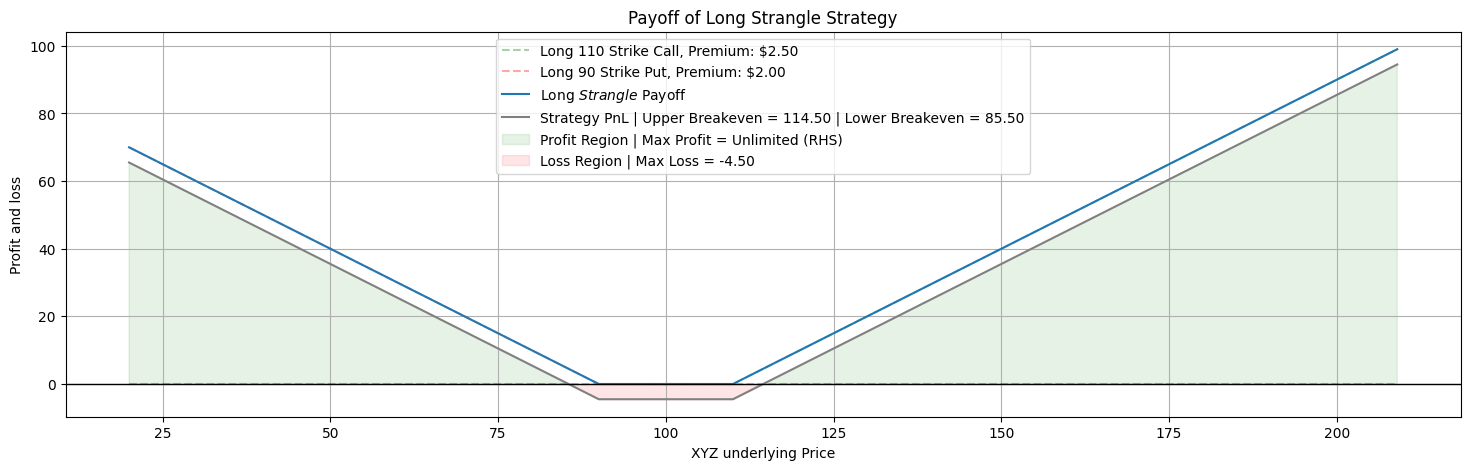

In [17]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_long_Call = 110
premium_long_Call = 2.50
strike_price_long_Put = 90
premium_long_Put = 2.00

# underlying price range at expiration of the Option
sT = np.arange(0.2*spot_price,2.1*spot_price,1)

# Long Put and Call Option payoff
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
xyz_payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")

# Long Strangle payoff and PnL
xyz_long_Strangle_payoff = xyz_payoff_long_Call + xyz_payoff_long_Put
xyz_long_Strangle_pnl = xyz_long_Strangle_payoff - (premium_long_Call + premium_long_Put)  # Since we are long both the call and the put, we need to subtract the total premium paid to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_long_Call,'--',label=f'Long 110 Strike Call, Premium: ${premium_long_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 90 Strike Put, Premium: ${premium_long_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_long_Strangle_payoff,label='Long $Strangle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_long_Put  - (premium_long_Call + premium_long_Put)
upper_be = strike_price_long_Call + (premium_long_Call + premium_long_Put)
  
# Profit region
ax.plot(sT, xyz_long_Strangle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_long_Strangle_pnl, 0, where=(xyz_long_Strangle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = Unlimited (RHS)')
ax.fill_between(sT, xyz_long_Strangle_pnl, 0, where=(xyz_long_Strangle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_long_Strangle_pnl)))

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Long Strangle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 7: Short Straddle

A **Short Straddle** options strategy involves going **Short** 1 $Call$ and **Short** 1 $Put$ of the same underlying, with the same strike price (usually ATM) and same expiration date.

This is the **opposite** of a long straddle: a **short volatility** play. You collect premium upfront and profit if the stock price stays relatively flat (within a range) until expiration. Maximum profit = total premium received. Risk is theoretically **unlimited** on both sides if the stock makes a large move.

**Payoff / Profit Formula at Expiration**

Profit = short call profit + short put profit:

$$
\text{Profit} = - \max(S_T - K, 0) + C - \max(K - S_T, 0) + P
$$

Which simplifies to:

$$
\text{Profit} = T - \max(S_T - K, K - S_T)
$$

or equivalently:

$$
\text{Profit} = (C + P) - |S_T - K|
$$

- Maximum profit = total premium received ($T$), occurs when $S_T = K$ (both options expire worthless)
- You lose money when $|S_T - K| > T$
- Breakevens: $K - T$ (lower) and $K + T$ (upper)

Consider the following example Short Straddle Strategy where we:
- **Short** a $Call$ with $\text{Strike Price} = {\$100}$
- **Short** a $Put$ with $\text{Strike Price} = {\$100}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$4.20$
- Premium received for the **Short** $Put$ is $\$3.80$


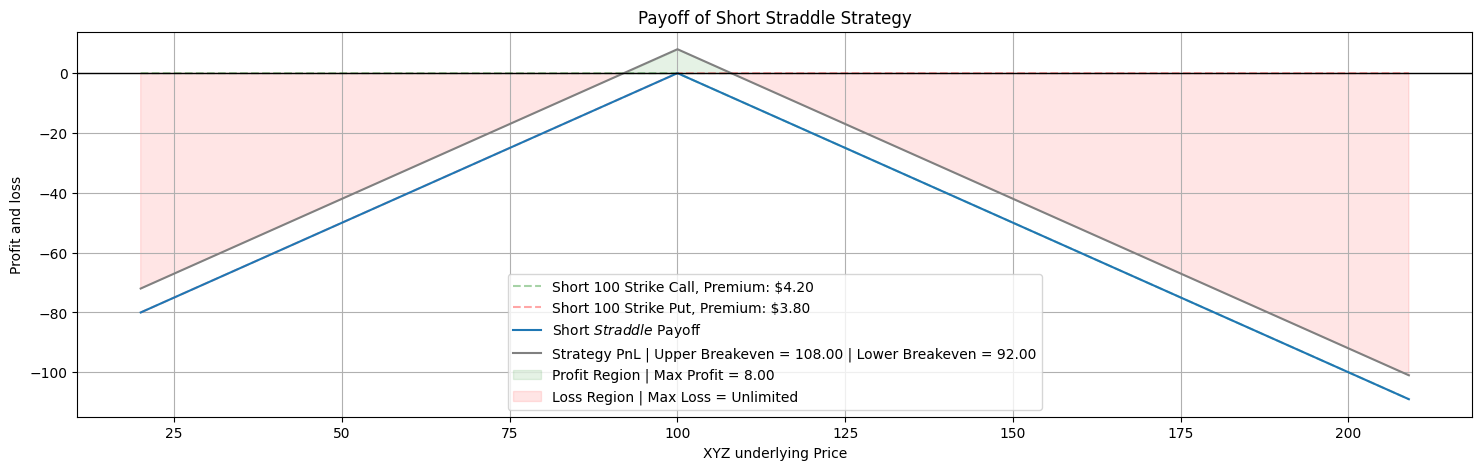

In [18]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_short_Call = 100
premium_short_Call = 4.20
strike_price_short_Put = 100
premium_short_Put = 3.80

# underlying price range at expiration of the Option
sT = np.arange(0.2*spot_price,2.1*spot_price,1)

# Short Put and Call Option payoff
xyz_payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
xyz_payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Short Straddle payoff and PnL
xyz_short_Straddle_payoff = xyz_payoff_short_Call + xyz_payoff_short_Put
xyz_short_Straddle_pnl = xyz_short_Straddle_payoff + (premium_short_Call + premium_short_Put)  # Since we are short both the call and the put, we receive the total premium and add then to the PnL

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 100 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Put,'--',label=f'Short 100 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_short_Straddle_payoff,label='Short $Straddle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_short_Put  - (premium_short_Call + premium_short_Put)
upper_be = strike_price_short_Call + (premium_short_Call + premium_short_Put)
  
# Profit region
ax.plot(sT, xyz_short_Straddle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_short_Straddle_pnl, 0, where=(xyz_short_Straddle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(premium_short_Call + premium_short_Put) )
ax.fill_between(sT, xyz_short_Straddle_pnl, 0, where=(xyz_short_Straddle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = Unlimited')

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Short Straddle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 8: Short Strangle

A **Short Strangle** is an options strategy that involves going **Short** one OTM $Call$ and going **Short** one OTM $Put$, of the same underlying with the same expiration date.

The only difference is that the $\text{Strike Price}$ of the $Call$ $>$ $\text{Current Price}$ $>$ $\text{Strike Price}$ of the $Put$ (both out-of-the-money)

This is a **short volatility** strategy, similar to a short straddle but with **wider profit zone** and **lower premium collected**. You profit if the stock price stays **between the two strikes** (or even a bit beyond, thanks to the credit received). Maximum profit = total premium received. Risk is **unlimited** on the upside and **substantial** on the downside.

**Payoff / Profit Formula at Expiration**

Profit = short call profit + short put profit:

$$
\text{Profit} = -\max(S_T - K_c, 0) + C - \max(K_p - S_T, 0) + P
$$

Which simplifies to:

$$
\text{Profit} = 
\begin{cases} 
T - (S_T - K_c) & \text{if } S_T > K_c \quad \text{(short call in-the-money)} \\[1.2em]
T - (K_p - S_T) & \text{if } S_T < K_p \quad \text{(short put in-the-money)} \\[1.2em]
T               & \text{if } K_p \leq S_T \leq K_c \quad \text{(both options expire worthless)}
\end{cases}
$$

or compactly:

$$
\text{Profit} = T - \max(S_T - K_c, K_p - S_T, 0)
$$

- Maximum profit = total credit received ($T$), achieved anywhere between $K_p$ and $K_c$
- Breakevens: $K_p - T$ (lower) and $K_c + T$ (upper)

Consider the following example Short Strangle Strategy where we:
- **Short** a $Call$ with $\text{Strike Price} = {\$110}$
- **Short** a $Put$ with $\text{Strike Price} = {\$90}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$2.50$
- Premium received for the **Short** $Put$ is $\$2.00$

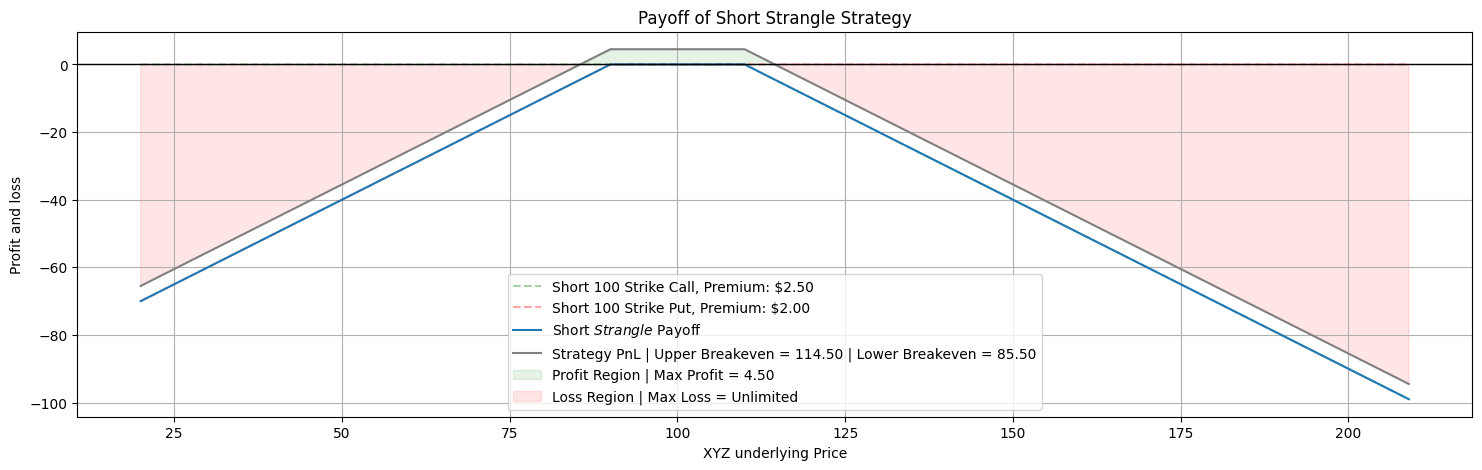

In [19]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_short_Call = 110
premium_short_Call = 2.50
strike_price_short_Put = 90
premium_short_Put = 2.00

# underlying price range at expiration of the Option
sT = np.arange(0.2*spot_price,2.1*spot_price,1)

# Short Put and Call Option payoff
xyz_payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
xyz_payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Short Strangle payoff and PnL
xyz_short_Strangle_payoff = xyz_payoff_short_Call + xyz_payoff_short_Put
xyz_short_Strangle_pnl = xyz_short_Strangle_payoff + (premium_short_Call + premium_short_Put)  # Since we are short both the call and the put, we receive the total premium and add then to the PnL

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 100 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Put,'--',label=f'Short 100 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_short_Strangle_payoff,label='Short $Strangle$ Payoff')
  
# Plot the profit/loss curve
lower_be = strike_price_short_Put  - (premium_short_Call + premium_short_Put)
upper_be = strike_price_short_Call + (premium_short_Call + premium_short_Put)
  
# Profit region
ax.plot(sT, xyz_short_Strangle_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_short_Strangle_pnl, 0, where=(xyz_short_Strangle_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(premium_short_Call + premium_short_Put) )
ax.fill_between(sT, xyz_short_Strangle_pnl, 0, where=(xyz_short_Strangle_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = Unlimited')

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Short Strangle Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 9: Iron Condor

A **Short Iron Condor** (classic credit version) is an options strategy where we  
- Sell 1 OTM $Put$ (Short $Put$)  
- Buy 1 further OTM $Put$ (Long $Put$ — protection)  
- Sell 1 OTM $Call$ (Short $Call$)  
- Buy 1 further OTM $Call$ (Long $Call$ — protection)  

All four legs have the **same expiration**, and this is a combination of a **bull put credit spread** + **bear call credit spread**. This is a **short volatility**, **range-bound** strategy: you collect net premium upfront and profit if the underlying stays **inside a wide range** until expiration. Risk is **defined** (unlike naked strangle/straddle).

Given the following parameters:
- $S_0$ = current underlying price
- $S_T$ = price at expiration
- $K_{p1}$ = long put strike (lowest, protection)
- $K_{p2}$ = short put strike ($K_{p1} < K_{p2} < S_0$)
- $K_{c1}$ = short call strike ($S_0 < K_{c1} < K_{c2}$)
- $K_{c2}$ = long call strike (highest, protection)
- Put spread width = $K_{p2} - K_{p1}$  
- Call spread width = $K_{c2} - K_{c1}$  
- Usually symmetric: put width = call width  
- Net credit received = $T$ = (short put premium + short call premium) − (long put premium + long call premium)

**Payoff / Profit Formula at Expiration**

$$
\text{Profit} = T - \left[ \max(K_{p2} - S_T, 0) - \max(K_{p1} - S_T, 0) \right] - \left[ \max(S_T - K_{c1}, 0) - \max(S_T - K_{c2}, 0) \right]
$$

Piecewise (most useful form):

$$
\text{Profit} = 
\begin{cases} 
T - (K_{p2} - K_{p1}) & \text{if } S_T < K_{p1} \quad \text{(max loss — put side)} \\[1.2em]
T + (S_T - K_{p2}) & \text{if } K_{p1} < S_T < K_{p2} \\[1.2em]
T & \text{if } K_{p2} \leq S_T \leq K_{c1} \quad \text{(max profit zone)} \\[1.2em]
T - (S_T - K_{c1}) & \text{if } K_{c1} < S_T < K_{c2} \\[1.2em]
T - (K_{c2} - K_{c1}) & \text{if } S_T > K_{c2} \quad \text{(max loss — call side)}
\end{cases}
$$

- Max profit = net credit $T$ (both spreads expire worthless)
- Max loss = spread width − $T$ (assuming symmetric wings; uses the wider wing if asymmetric)
- Breakevens: Lower = $K_{p2} - T$ ; Upper = $K_{c1} + T$

Consider the following example Iron Condor Strategy where we:
- **Long** a $Put$ with $\text{Strike Price} = {\$90}$
- **Short** a $Put$ with $\text{Strike Price} = {\$95}$
- **Long** a $Call$ with $\text{Strike Price} = {\$105}$
- **Short** a $Call$ with $\text{Strike Price} = {\$110}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$2.30$
- Premium received for the **Short** $Put$ is $\$2.10$
- Premium paid for the **Long** $Call$ is $\$0.90$
- Premium paid for the **Long** $Put$ is $\$0.80$

Quick Calculations before moving forward:

→ Put credit = 2.10 − 0.80 = $1.30  
→ Call credit = 2.30 − 0.90 = $1.40  
→ Net credit $T = 2.70$ (per share, ×100 = $270 credit)


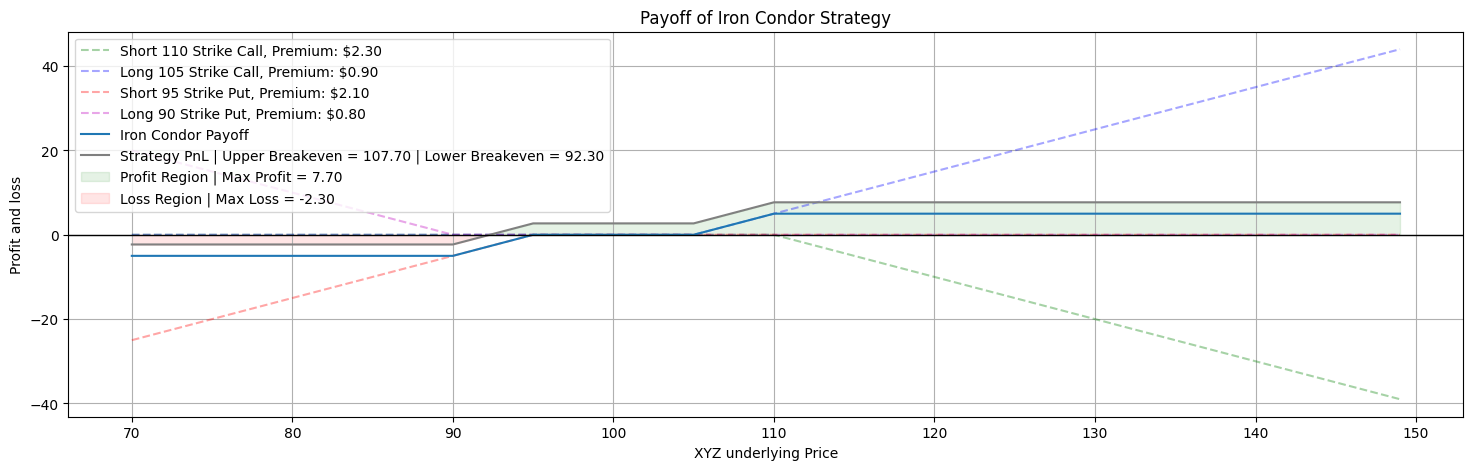

In [20]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_long_Put = 90
premium_long_Put = 0.80
strike_price_short_Put = 95
premium_short_Put = 2.10

strike_price_long_Call = 105
premium_long_Call = 0.90
strike_price_short_Call = 110
premium_short_Call = 2.30

# underlying price range at expiration of the Option
sT = np.arange(0.7*spot_price,1.5*spot_price,1)

# Payoff of the 4 individual options
xyz_payoff_long_Put = put_payoff(sT, strike_price_long_Put, action="long")
xyz_payoff_short_Put = put_payoff(sT, strike_price_short_Put, action="short")
xyz_payoff_long_Call = call_payoff(sT, strike_price_long_Call, action="long")
xyz_payoff_short_Call = call_payoff(sT, strike_price_short_Call, action="short")

# Iron Condor payoff and PnL
xyz_Iron_Condor_payoff = xyz_payoff_long_Call + xyz_payoff_short_Call + xyz_payoff_long_Put + xyz_payoff_short_Put
net_premium = (premium_short_Call + premium_short_Put) - (premium_long_Call + premium_long_Put)  # We receive the premium from the short call and put, and we pay the premium for the long call and put, so we subtract the total premium paid from the total premium received to get the net premium.
xyz_Iron_Condor_pnl = xyz_Iron_Condor_payoff + net_premium  # Since we receive the net premium, we add it to the payoff to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 110 Strike Call, Premium: ${premium_short_Call:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Call,'--',label=f'Long 105 Strike Call, Premium: ${premium_long_Call:.2f}',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Put,'--',label=f'Short 95 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put,'--',label=f'Long 90 Strike Put, Premium: ${premium_long_Put:.2f}',color='m', alpha=0.35)
ax.plot(sT,xyz_Iron_Condor_payoff,label='Iron Condor Payoff')
  
lower_be = strike_price_short_Put  - net_premium
upper_be = strike_price_long_Call + net_premium
  
# Profit region
ax.plot(sT, xyz_Iron_Condor_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_Iron_Condor_pnl, 0, where=(xyz_Iron_Condor_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(max(xyz_Iron_Condor_pnl)) )
ax.fill_between(sT, xyz_Iron_Condor_pnl, 0, where=(xyz_Iron_Condor_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_Iron_Condor_pnl)) )

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Iron Condor Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 10: Long Butterfly Spread / $Call$ Fly

A **Long Butterfly Spread** (classic debit version) is an options strategy that uses **four options** at **three equidistant strikes**:  
- Buy 1 lower-strike option (wing)  
- Sell 2 middle-strike options (body)  
- Buy 1 higher-strike option (wing)  

All same expiration, same type (all $Calls$ **or** all $Puts$). It is a **market-neutral, low-volatility** strategy: you pay a small debit upfront and profit maximally if the underlying **pins exactly** (or very close) to the middle strike at expiration.

Given the following key Parameters
- $S_0$ = current underlying price
- $S_T$ = price at expiration
- $K_l$ = lower strike (long wing, usually ITM or near ATM)
- $K_m$ = middle strike (short 2 options, usually ATM or target pin)
- $K_h$ = higher strike (long wing)
- Wing width = $d = K_m - K_l = K_h - K_m$ (symmetric)
- Net debit paid = $D$ (total cost of longs minus credit from 2 shorts)

**Payoff / Profit Formula at Expiration**

$$
\text{Profit} = \max(S_T - K_l, 0) - 2 \cdot \max(S_T - K_m, 0) + \max(S_T - K_h, 0) - D \quad \text{(call version)}
$$

or equivalently (piecewise):

$$
\text{Profit} = 
\begin{cases} 
0 - D & \text{if } S_T \leq K_l \quad \text{(all expire worthless or net zero)} \\[1.2em]
(S_T - K_l) - D & \text{if } K_l < S_T < K_m \\[1.2em]
(S_T - K_l) - 2(S_T - K_m) - D = (2K_m - K_l - S_T) - D & \text{if } K_m \leq S_T \leq K_h \\[1.2em]
(S_T - K_l) - 2(S_T - K_m) + (S_T - K_h) - D = 0 - D & \text{if } S_T \geq K_h
\end{cases}
$$

- Max profit = $d - D$ → occurs **exactly** at $S_T = K_m$
- Max loss = $D$ (net debit paid) → occurs if $S_T \leq K_l$ or $S_T \geq K_h$
- Breakevens: Lower = $K_l + D$ ; Upper = $K_h - D$

(For **put butterfly**, the formula mirrors but uses put payoffs; payoff shape is identical.)

Consider the following example Long Butterfly Strategy where we:
- **Long** a $Call$ with $\text{Strike Price} = {\$95}$
- **Short** two $Calls$ with $\text{Strike Price} = {\$100}$
- **Long** a $Call$ with $\text{Strike Price} = {\$105}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$3.10$ each
- Premium paid for the **Long** $Call$ with $\text{Strike Price} = {\$95}$ is $\$7.00$
- Premium paid for the **Long** $Call$ with $\text{Strike Price} = {\$105}$ is $\$1.20$

Quick Calculations before moving forward:

→ Net debit $D = (7.00 + 1.20) - 6.20 = \$2.00$  
→ Wing width $d = 5$ → Max profit = $5 - 2 = \$3.00$ ($300 per contract)

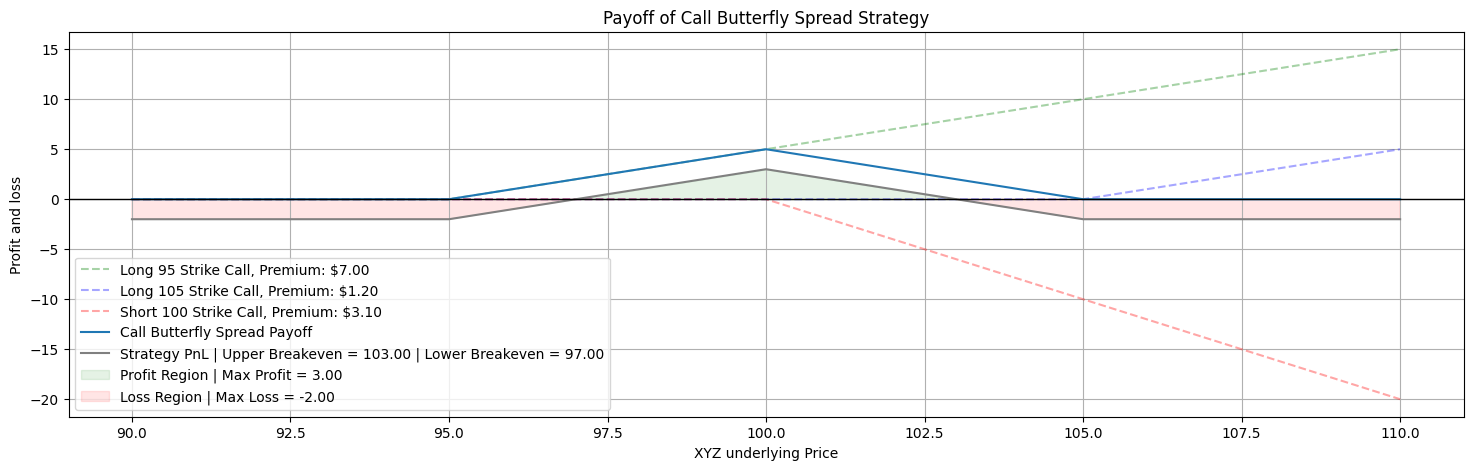

In [21]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_long_Call_1 = 95
premium_long_Call_1 = 7.00
strike_price_long_Call_2 = 105
premium_long_Call_2 = 1.20
strike_price_short_Call = 100
premium_short_Call = 3.10

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.1*spot_price,1)

# Payoff of the 3 individual options
xyz_payoff_long_Call_1 = call_payoff(sT, strike_price_long_Call_1, action="long")
xyz_payoff_long_Call_2 = call_payoff(sT, strike_price_long_Call_2, action="long")
xyz_payoff_short_Call = 2 * call_payoff(sT, strike_price_short_Call, action="short") # Multiply by 2 since we are short 2 call options at the same strike price.

# Call Butterfly Spread payoff and PnL
xyz_Call_Butterfly_payoff = xyz_payoff_long_Call_1 + xyz_payoff_long_Call_2 + xyz_payoff_short_Call
net_premium = premium_long_Call_1 + premium_long_Call_2 - 2 * premium_short_Call  # We pay the premium for the 2 long calls and receive the premium for the short call, so we subtract the total premium paid from the total premium received to get the net premium.
xyz_Call_Butterfly_pnl = xyz_Call_Butterfly_payoff - net_premium  # Since we pay the net premium, we subtract it from the payoff to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_long_Call_1,'--',label=f'Long 95 Strike Call, Premium: ${premium_long_Call_1:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Call_2,'--',label=f'Long 105 Strike Call, Premium: ${premium_long_Call_2:.2f}',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Call,'--',label=f'Short 100 Strike Call, Premium: ${premium_short_Call:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_Call_Butterfly_payoff,label='Call Butterfly Spread Payoff')

# Breakeven points
lower_be = strike_price_long_Call_1 + net_premium
upper_be = strike_price_long_Call_2 - net_premium

# Profit region
ax.plot(sT, xyz_Call_Butterfly_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_Call_Butterfly_pnl, 0, where=(xyz_Call_Butterfly_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(max(xyz_Call_Butterfly_pnl)) )
ax.fill_between(sT, xyz_Call_Butterfly_pnl, 0, where=(xyz_Call_Butterfly_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_Call_Butterfly_pnl)) )

plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Call Butterfly Spread Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

#### Option Strategy 11: Short Butterfly Spread / $Put$ Fly

A **Long Put Butterfly** (aka Put Fly or Long Put Fly) is an options strategy where one:
- Buy 1 higher-strike $Put$ (upper wing, often ITM)  
- Sell 2 middle-strike $Puts$ (body, usually ATM or target pin)  
- Buy 1 lower-strike $Put$ (lower wing, OTM)  

All $Puts$ have the **same expiration** and **equidistant strikes** (symmetric wings). It is a **neutral to slightly bearish** (if upper wing ITM), **low-volatility** strategy: pay a small net debit and profit most if the stock **pins very close to the middle strike** at expiration.

Given the following key parameters:
- $S_0$ = current underlying price
- $S_T$ = price at expiration
- $K_h$ = higher strike (long 1 put)  
- $K_m$ = middle strike (short 2 puts)  
- $K_l$ = lower strike (long 1 put)  
- Wing width $d = K_h - K_m = K_m - K_l$ (symmetric)  
- Net debit paid = $D$ = (premium of higher put + premium of lower put) − (2 × premium of middle put)

**Payoff / Profit Formula at Expiration**

$$
\text{Profit} = \max(K_h - S_T, 0) - 2 \cdot \max(K_m - S_T, 0) + \max(K_l - S_T, 0) - D
$$

Piecewise breakdown:

$$
\text{Profit} = 
\begin{cases} 
-D & \text{if } S_T \geq K_h \quad \text{(all worthless or net zero)} \\[1.2em]
K_h - S_T - D & \text{if } K_m \leq S_T < K_h \\[1.2em]
2K_m - K_h - S_T - D & \text{if } K_l < S_T < K_m \\[1.2em]
-D & \text{if } S_T \leq K_l
\end{cases}
$$

- **Max profit** = $d - D$ → at exactly $S_T = K_m$  
- **Max loss** = $D$ (net debit) → if $S_T \geq K_h$ or $S_T \leq K_l$  
- **Breakevens**: Lower = $K_l + D$ ; Upper = $K_h - D$

(The shape and breakevens are **identical** to the $Call$ butterfly — only the legs change.)

Consider the following example Short Butterfly Strategy where we:
- **Long** a $Put$ with $\text{Strike Price} = {\$95}$
- **Short** two $Puts$ with $\text{Strike Price} = {\$100}$
- **Long** a $Put$ with $\text{Strike Price} = {\$105}$
- $\text{Spot Price} = {\$100}$
- Premium received for the **Short** $Call$ is $\$3.50$ each
- Premium paid for the **Long** $Call$ with $\text{Strike Price} = {\$95}$ is $\$1.60$
- Premium paid for the **Long** $Call$ with $\text{Strike Price} = {\$105}$ is $\$6.90$

Quick Calculations before moving forward:

→ Net debit $D = (6.90 + 1.60) - 7.00 = \$1.50$
→ Wing width $d = 5$ → Max profit = $5 - 1.50 = \$3.50$ ($350 per contract)



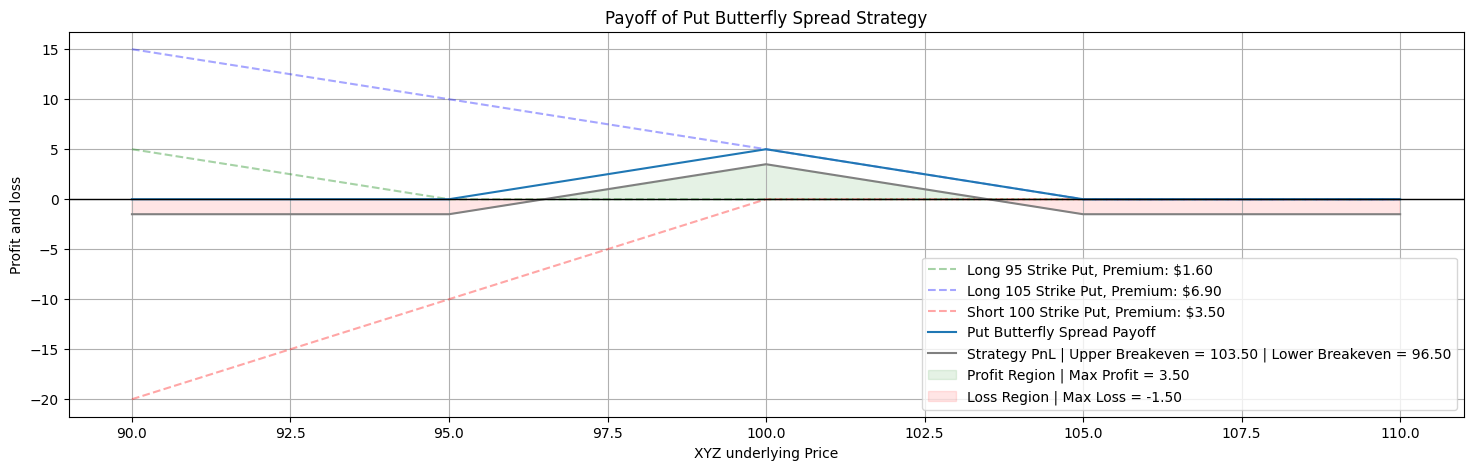

In [22]:
# Adjust the param to your liking to see how the payoff changes
spot_price = 100
strike_price_long_Put_1 = 95
premium_long_Put_1 = 1.60
strike_price_long_Put_2 = 105
premium_long_Put_2 = 6.90
strike_price_short_Put = 100
premium_short_Put = 3.50

# underlying price range at expiration of the Option
sT = np.arange(0.9*spot_price,1.1*spot_price,1)

# Payoff of the 3 individual options
xyz_payoff_long_Put_1 = put_payoff(sT, strike_price_long_Put_1, action="long")
xyz_payoff_long_Put_2 = put_payoff(sT, strike_price_long_Put_2, action="long")
xyz_payoff_short_Put = 2 * put_payoff(sT, strike_price_short_Put, action="short") # Multiply by 2 since we are short 2 put options at the same strike price.

# Put Butterfly Spread payoff and PnL
xyz_Put_Butterfly_payoff = xyz_payoff_long_Put_1 + xyz_payoff_long_Put_2 + xyz_payoff_short_Put
net_premium = premium_long_Put_1 + premium_long_Put_2 - 2 * premium_short_Put # We pay the premium for the 2 long puts and receive the premium for the short put
xyz_Put_Butterfly_pnl = xyz_Put_Butterfly_payoff - net_premium  # Since we pay the net premium, we subtract it from the payoff to get the PnL.

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(sT,xyz_payoff_long_Put_1,'--',label=f'Long 95 Strike Put, Premium: ${premium_long_Put_1:.2f}',color='g', alpha=0.35)
ax.plot(sT,xyz_payoff_long_Put_2,'--',label=f'Long 105 Strike Put, Premium: ${premium_long_Put_2:.2f}',color='b', alpha=0.35)
ax.plot(sT,xyz_payoff_short_Put,'--',label=f'Short 100 Strike Put, Premium: ${premium_short_Put:.2f}',color='r', alpha=0.35)
ax.plot(sT,xyz_Put_Butterfly_payoff,label='Put Butterfly Spread Payoff')

# Breakeven points
lower_be = strike_price_long_Put_1 + net_premium
upper_be = strike_price_long_Put_2 - net_premium

# Profit region
ax.plot(sT, xyz_Put_Butterfly_pnl, label=f"Strategy PnL | Upper Breakeven = {upper_be:.2f} | Lower Breakeven = {lower_be:.2f}", color='grey')
ax.fill_between(sT, xyz_Put_Butterfly_pnl, 0, where=(xyz_Put_Butterfly_pnl > 0), interpolate=True, alpha=0.1, color='green', label='Profit Region | Max Profit = {:.2f}'.format(max(xyz_Put_Butterfly_pnl)) )
ax.fill_between(sT, xyz_Put_Butterfly_pnl, 0, where=(xyz_Put_Butterfly_pnl < 0), interpolate=True, alpha=0.1, color='red', label='Loss Region | Max Loss = {:.2f}'.format(min(xyz_Put_Butterfly_pnl)) )
plt.axhline(0, color='k', linestyle='-', linewidth=1.0)  # x-axis at zero payoff
plt.title('Payoff of Put Butterfly Spread Strategy')
plt.xlabel('XYZ underlying Price')
plt.ylabel('Profit and loss')
plt.grid()
plt.legend()
plt.show()

### 3. Black-Scholes Option Pricing Model

The **Black-Scholes model** (1973, by Fischer Black, Myron Scholes, and Robert Merton) revolutionized options pricing. It provides a **closed-form analytical solution** for the theoretical fair value of **European-style** call and put options (no early exercise). The model assumes the underlying follows a geometric Brownian motion and derives a unique no-arbitrage price.

This is the foundation of modern derivatives pricing — used daily in trading, risk management, and option valuation (including employee stock options).

#### Key Assumptions (Critical – Real Markets Violate Many)

The model holds only under these idealized conditions:

| **Assumption**                     | **Description**                                                     | **Real-World Violation Examples**                  |
|----------------------------------|---------------------------------------------------------------------|--------------------------------------------------|
| No dividends during option life  | Underlying pays no dividends (or continuous dividend yield q = 0)   | Most stocks pay dividends                        |
| Constant risk-free rate r        | Borrowing/lending at known, constant rate                           | Interest rates change over time                  |
| Constant volatility σ            | Volatility is known and does not change                             | Volatility is stochastic (smiles, skews)         |
| Lognormal asset prices           | Stock price follows geometric Brownian motion (continuous, no jumps)| Real prices have jumps (earnings, news)          |
| No transaction costs / taxes     | Frictionless trading, infinite liquidity                            | Commissions, bid-ask spreads exist               |
| Continuous trading               | Can hedge/rebalance continuously                                    | Trading happens in discrete time                 |
| No arbitrage                     | Markets are efficient; riskless profit impossible                   | Arbitrage opportunities sometimes appear         |
| European style only              | Option exercised only at expiration                                 | American options allow early exercise            |

**Violations → Extensions:**  
Black-Scholes can be extended to handle real-world violations, such as:
- Dividends → Dividend-adjusted models  
- Stochastic volatility → Heston model  
- Price jumps → Jump-diffusion models  

#### Black-Scholes Formulas

The Black-Scholes formula for option pricing is formally written as follow:

**Call option price** $C(S_t, t)$:

$$
C = S_t \, N(d_1) - K \, e^{-r(T-t)} \, N(d_2)
$$

**Put option price** $P(S_t, t)$:

$$
P = K \, e^{-r(T-t)} \, N(-d_2) - S_t \, N(-d_1)
$$

Where:

$$
d_1 = \frac{\ln(S_t / K) + (r + \frac{1}{2}\sigma^2)(T)}{\sigma \sqrt{T}}
$$

$$
d_2 = d_1 - \sigma \sqrt{T}
$$

Given the following parameters:
- $S_t$ = current underlying price  
- $K$   = strike price  
- $r$   = continuously compounded risk-free rate  
- $T$ = time to expiration (in years)  
- $\sigma$ = annualized volatility of underlying returns  
- $N(\cdot)$ = cumulative distribution function (CDF) of standard normal distribution

**Interpretation** (intuitive):
- $N(d_1)$ ≈ delta ≈ probability call finishes in-the-money (risk-neutral measure, adjusted)
- $N(d_2)$ ≈ probability call exercised (actual probability under risk-neutral measure)
- First term = expected value of receiving stock if exercised (discounted)
- Second term = expected value of paying strike if exercised (discounted)

**Put-call parity** (model-independent, holds under no-arbitrage):

$$
C - P = S_t - K \, e^{-r(T)} \quad \text{(non-dividend case)}
$$

#### Why It Matters

The Black-Scholes model is significant because it provided the first closed-form analytical solution for pricing European options, offering a mathematically elegant and computationally efficient way to determine fair option values without relying on simulation or approximation methods. It introduced the powerful concept of risk-neutral valuation, demonstrating that an option's price equals the discounted expected payoff under a specially constructed "risk-neutral" probability measure, where the underlying asset grows at the risk-free rate—eliminating the need to estimate investors' risk preferences. From the model's equations, the famous option Greeks (Delta, Gamma, Theta, Vega, and Rho) can be derived analytically as partial derivatives, giving traders precise, real-time sensitivity measures for managing risk and constructing hedges. 

Furthermore, the Black-Scholes framework laid the theoretical foundation for many subsequent numerical pricing techniques, including binomial trees, Monte Carlo simulations, and finite-difference solutions to partial differential equations.

Despite its elegance, the model has well-known limitations. It does not accommodate American-style options, which allow early exercise (requiring numerical methods like binomial trees instead). It assumes volatility is constant over the option's life, whereas real markets exhibit volatility smiles, skews, and term structures, prompting the widespread use of implied volatility surfaces or more advanced stochastic volatility models such as Heston. The model also assumes continuous price paths with no jumps, an assumption frequently violated by sudden news-driven moves, leading to extensions like the Merton jump-diffusion model, Heston stochastic volatility, and SABR dynamics. 

Nevertheless, more than fifty years after its introduction, the Black-Scholes model remains the unchallenged benchmark in options markets. Even when its assumptions are clearly violated, traders and quants continue to express option prices in terms of Black-Scholes implied volatility—making it the universal language and common reference point across the entire derivatives industry.

In [23]:
# Define a function to compute the price of an option given the BS-model and the respective parameters
def black_scholes_price(S, K, T, r, sigma, option_type="call"):
  d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
  d2 = d1 - sigma * np.sqrt(T)
  if option_type == "call": # Call option
    price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
  else:  # Put option
    price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
  return price

Using the above example, we can compute price of the $Call$ and $Put$ option for the underlying with the following information:
- Stock $S = \$100$
- Strike Price $K = \$100$ (ATM)
- $r = 5\%$
- $\sigma = 20\%$
- $T = 1$ year

In [24]:
print("Price of a call option with S=100, K=100, T=1 year, r=5% and sigma=20%: $", round(black_scholes_price(100, 100, 1, 0.05, 0.2, option_type="call"), 2))
print("Price of a put option with S=100, K=100, T=1 year, r=5% and sigma=20%: $", round(black_scholes_price(100, 100, 1, 0.05, 0.2, option_type="put"), 2))

Price of a call option with S=100, K=100, T=1 year, r=5% and sigma=20%: $ 10.45
Price of a put option with S=100, K=100, T=1 year, r=5% and sigma=20%: $ 5.57


We can also compute the price of a $Call$ / $Put$ given either one, using the Put-Call Parity formula

In [25]:
call_price = 10.45

# Compute the price of the Put using the put-call parity relationship
put_price = call_price - 100 + 100 * np.exp(-0.05 * 1)
print("Price of the put option using put-call parity: $", round(put_price, 2))
assert(round(put_price, 2) == round(black_scholes_price(100, 100, 1, 0.05, 0.2, option_type="put"), 2))
print("They are the same!")

Price of the put option using put-call parity: $ 5.57
They are the same!


#### Historical vs Implied Volatility

Volatility in financial terms refers to the extent of variation in the trading price of a security or market index over a period. It measures the range of returns for a given security or market index. High volatility indicates higher risk and potential reward, while low volatility suggests a more stable investment.

**Historical Volatility**

Historical volatility (HV) measures the fluctuation in returns for a given security or market index over a specific past period. It is calculated based on historical market prices and provides insights into how much an asset's price has fluctuated historically.

- Step 1: Collect Historical Prices: Gather the daily closing prices for the asset over the desired period.
- Step 2: Calculate Daily Returns: Compute the daily returns using the natural logarithm of the ratio of consecutive closing prices.
- Step 3: Compute the Mean Return: Calculate the average of the daily returns.
- Step 4: Variance and Standard Deviation: Determine the variance of the daily returns and then take the square root to get the standard deviation, which represents historical volatility.

**Implied Volatility**

Implied volatility (IV) represents the market's forecast of future price movements for an asset. It is derived from the option's price and reflects market expectations of future volatility. Unlike historical volatility, which looks back at past prices, implied volatility is forward-looking.

- Step 1: Option Price: Obtain the current market price of the option.
- Step 2: Inputs for the Model: Input the current asset price, strike price, time to expiration, risk-free interest rate, and the option's market price into the model.
- Step 3: Solve for IV: Use numerical methods to solve for the implied volatility that, when input into the model, matches the observed market price of the option.

In [26]:
# Defining a function to compute historical volatility
def historical_volatility(ticker, period="1y", window_days=21):
  """Calculates rolling and total historical volatility (annualized)"""
  df = yf.download(ticker, period=period, progress=False)
  df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
  
  # Rolling HV
  df['hv_rolling'] = df['log_ret'].rolling(window=window_days).std() * np.sqrt(252) * 100
  return df

**Newton-Raphson Implementation - Estimating Implied Volatility using the Black Scholes Model**

Given the Black Scholes Model, we can use the Newton-Raphson approach to estimate implied volatility.

In [27]:
# Defining a function to compute Vega, which is the sensitivity of the option price to changes in volatility. Vega is the same for both call and put options.
def vega(S, K, T, r, sigma):
  """Vega — same for call & put"""
  if T <= 0:
    return 0.0
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
  return S * norm.pdf(d1) * np.sqrt(T)

# Newton-Raphson method to find the implied volatility given a market price of an option
def implied_volatility_newton(S, K, T, r, market_price, option_type="call", sigma_guess=0.3, tol=1e-6, max_iterations=100):
  """Calculate implied volatility using Newton-Raphson method."""
  sigma = sigma_guess
  for i in range(max_iterations):
    price = black_scholes_price(S, K, T, r, sigma, option_type)
    vega_value = vega(S, K, T, r, sigma)
    
    # Avoid division by zero
    if vega_value == 0:
      print("Vega is zero. No solution found.")
      return None
    
    price_diff = price - market_price
    if abs(price_diff) < tol:
      return sigma
    
    sigma -= price_diff / vega_value
  
  print("Max iterations reached. No solution found.")
  return None

With that, we can estimate the implied volatility for a stock given information on:
- Spot price
- Strike price
- Time to expiry
- Risk-Free rate
- Call/Put price

First, let us pull some Option data for a ticker in YFinance

In [28]:
def option_dataframe(stock_ticker):
  expirations = yf.Ticker(stock_ticker).options

  options_df = pd.DataFrame()
  for exp in expirations:
    opt = yf.Ticker(stock_ticker).option_chain(exp)
    calls = opt.calls
    puts = opt.puts
    calls['optionType'] = 'call'
    puts['optionType'] = 'put'
    calls['expirationDate'] = exp
    puts['expirationDate'] = exp
    options_df = pd.concat([options_df, calls, puts], ignore_index=True)

  options_df[['bid', 'ask', 'strike']] = options_df[['bid', 'ask', 'strike']].apply(pd.to_numeric)
  options_df = options_df.drop(columns = ['contractSize', 'currency', 'change', 'percentChange', 'lastTradeDate', 'lastPrice'])

  return options_df


In [29]:
aapl_options = option_dataframe("AAPL")
aapl_options.head(15)

,contractSymbol,strike,bid,ask,volume,openInterest,impliedVolatility,inTheMoney,optionType,expirationDate
0,AAPL260323C00210000,210.0,36.20,39.35,NaN,1.0,1.739259,True,call,2026-03-23
1,AAPL260323C00220000,220.0,26.25,29.35,1.0,6.0,1.363773,True,call,2026-03-23
2,AAPL260323C00225000,225.0,21.25,24.40,2.0,6.0,1.188969,True,call,2026-03-23
3,AAPL260323C00230000,230.0,16.25,19.20,7.0,19.0,0.947266,True,call,2026-03-23
4,AAPL260323C00232500,232.5,13.80,16.25,85.0,16.0,0.736331,True,call,2026-03-23
5,AAPL260323C00235000,235.0,11.30,13.95,9.0,23.0,0.698245,True,call,2026-03-23
6,AAPL260323C00237500,237.5,9.25,11.15,22.0,24.0,0.532231,True,call,2026-03-23
7,AAPL260323C00240000,240.0,7.80,8.45,207.0,72.0,0.392096,True,call,2026-03-23
8,AAPL260323C00245000,245.0,3.80,4.05,2459.0,173.0,0.308601,True,call,2026-03-23
9,AAPL260323C00247500,247.5,2.19,2.30,5733.0,390.0,0.279548,True,call,2026-03-23


The data above was calculated from YFinance. The following shows an example of how we can manually compute IV given the following parameters

In [30]:
# AAPL-like example – March 2026
S = 225.40          # spot price
K = 230.00
T = 45/365.0        # ~1.5 months
r = 0.042           # risk-free rate ~4.2%
market_call_price = 8.75

iv = implied_volatility_newton(S, K, T, r, market_call_price, option_type="call", sigma_guess=0.3, tol=1e-6, max_iterations=100)
print(f"Implied volatility: {iv:.4%}")   # e.g. ≈ 28.15%

Implied volatility: 32.6056%


### 4. Option Greeks

**Option Greeks** are a set of risk measures (partial derivatives) that quantify how an option's theoretical price is expected to change in response to small changes in key input variables — such as the underlying asset price, time to expiration, implied volatility, and interest rates.

They serve as the "dashboard" for options traders, helping to:
- Understand directional exposure and convexity
- Quantify time decay and volatility risk
- Manage portfolio sensitivities (delta-neutral, vega-neutral, etc.)
- Anticipate how positions behave under different market scenarios

By mastering the Greeks, traders gain deeper insight into **risk**, **reward**, and **trade-offs**, enabling more precise hedging, position sizing, and strategy selection.

In this section of the notebook we will cover:

1. The **five primary (first-order) Greeks** — the ones used by almost every options trader daily  
2. Selected **higher-order (second- and cross-) Greeks** — increasingly important in professional and volatility trading  
3. Intuitive explanations, typical signs, practical interpretations, and real-world applications

#### Primary (First-Order) Greeks

These measure the **direct** sensitivity of the option price to one input variable (all else equal).

| Greek   | Symbol | Measures sensitivity to            | Call sign | Put sign | Typical magnitude (ATM) | Practical trader interpretation                                      |
|---------|--------|-----------------------------------|-----------|----------|--------------------------|------------------------------------------------------------------------|
| **Delta**  | Δ      | Underlying price (S)              | +         | –        | ~0.50 / –0.50            | ≈ $ change in option per $1 move in stock <br> ≈ Probability ITM (rough) |
| **Theta**  | Θ      | Passage of time (days)            | –         | –        | –0.05 to –0.30           | Daily time decay — usually the enemy of long options                   |
| **Vega**   | ν      | Implied volatility (1% change)    | +         | +        | 0.10 – 0.40              | $ change per 1% move in IV — key for volatility trades                 |
| **Rho**    | ρ      | Risk-free interest rate (1% change)| +         | –        | 0.01 – 0.10              | Usually minor for equity options; matters more for LEAPs / rates       |
| **Gamma**  | Γ      | Change in Delta (second-order)    | +         | +        | 0.02 – 0.10              | Rate of change of delta — measures **convexity** / acceleration        |


#### Higher-Order & Cross Greeks (Selected)

These measure **changes in the primary Greeks** themselves — very useful for understanding non-linear behavior, especially near expiration, during volatility shocks, or in large portfolios.

| Greek                 | Measures                                      | Also called             | Sign (long option) | Highest when...                  | Practical use case                                              |
|----------------------|----------------------------------------------|--------------------------|--------------------|----------------------------------|------------------------------------------------------------------|
| **Vanna**            | Change in Delta w.r.t. implied volatility    | DdeltaDvol               | Varies             | Near ATM, medium/long tenor      | Explains delta-hedge rebalancing after vol moves                |
| **Vomma / Volga**    | Change in Vega w.r.t. implied volatility     | DvegaDvol                | + (long straddle)  | ATM, longer-dated options        | Sensitivity to volatility-of-volatility (convexity in vol)      |
| **Charm**            | Change in Delta w.r.t. passage of time       | Delta decay / DdeltaDtime| Varies             | Near expiration, near ATM        | How delta drifts as expiration approaches                       |
| **Color / Gamma decay** | Change in Gamma w.r.t. passage of time    | DgammaDtime              | +                  | Short-dated ATM options          | How gamma (convexity) decays over time                          |
| **Speed**            | Change in Gamma w.r.t. underlying price      | DgammaDspot              | Varies             | Near ATM                         | Third-order — gamma convexity changes                           |
| **Ultima**           | Change in Vomma w.r.t. volatility            | —                        | —                  | Long-dated, high vomma positions | Very high-order vol-of-vol-of-vol risk                          |

> **Note**: Most retail platforms display only Delta, Gamma, Theta, Vega, and sometimes Rho.  
> Higher-order Greeks (Vanna, Vomma, Charm, etc.) appear mainly in professional volatility desks, market-making systems, and advanced analytics tools.


#### 4.0 Initialising Functions for Greek Computation

**Function 1: ```greeks_component()```**

We will first define a function that computes 
- Volatility
- Dividend Yield
- Risk-Free Rate

Which are all components required for Greeks

In [31]:
def greeks_components(ticker, period='1y'):
  """
  Inputs:
    ticker: Ticker of the underlying asset
    period: The date range / period of analysis (e.g. '1y' for 1 year, '6mo' for 6 months, etc.)
  Output: 
    The volatility/standard deviation of the returns, the dividend yield of the stock, and the risk free interest rate
  """
  df = yf.Ticker(ticker).history(period='1y')
  
  # Calculate the Volatility
  df_rets = df['Close'].apply(lambda x: np.log(x)) - df['Close'].shift(1).apply(lambda x: np.log(x))
  df_rets = df_rets.dropna() # Remove the first NaN value resulting from the shift operation
  volatility = df_rets.std() # Remove the first NaN value and calculate the volatility
  
  # Calculate the Dividend Yield
  div_yield = df['Dividends'].sum() / df['Close'].mean()
  
  #Calculate the Risk-free Interest rate
  data_source = 'fred' # Our data source is (FRED) 
  rf_rate_ticker = 'DGS1' # The risk-free interest rate ticker symbol
  rf_rate = pdr.DataReader(rf_rate_ticker, data_source) # Get the risk-free interest rate data
  rf_rate = rf_rate['DGS1'].iloc[-1]/100
  
  return volatility, div_yield, rf_rate

**Function 2: ```normal_cdf()```**

The second function calculates the cumulative density function of a normal distribution. It estimates the probability of a stock price being above or below a certain $\text{Strike Price}$.

In [32]:
def normal_cdf(mu, sigma, x):
  """
  Inputs:
    mu: The expected value/mean of the function
    sigma: Standard deviation of the function
    x: Value of the X in the cdf function
  Output: 
    Cummulative density function of a normal distribution
  """
  # Calculating the cummulative density function
  return 0.5 * (1 + math.erf((x - mu) / (sigma * np.sqrt(2))))

**Function 3: ```bse_delta()```**


The third function calculates the value of $N(d_{1})$, $d_{1}$, $N(d_{2})$, and $d_{2}$. These are important variables used in the Black-Scholes equation for pricing options. $N(d_{1})$ and $N(d_{2})$ represent the probability that the option will be exercised, while $d_{1}$ and $d_{2}$ represent the sensitivity of the option price to changes in the underlying stock price and time to expiration.

In [33]:
def bse_delta(ex_price, int_rate, div_yield, cur_price, time, option_type, vol):
  """
  Inputs:
    ex_price: Exercise price of the option.
    int_rate: Risk-free interest rate.
    cur_price: Current underlying price of the asset.
    time: Time to expiry of the option.
    vol: Volatility of the option.
    option_type: Type of the option whether Call or Put.
  Output: 
    N(d1) and N(d2) for calculating the Call Option
  """
  d1 = (np.log(cur_price/ex_price)+(int_rate - div_yield + (vol**2)/2)*time )/(vol * np.sqrt(time))
  d2 = (np.log(cur_price/ex_price)+(int_rate - div_yield - (vol**2)/2)*time )/(vol * np.sqrt(time))
  
  # use 'normal_cdf' to calculate N(d1) and N(d2)
  N_d1 = normal_cdf(0, 1, d1)
  N_d2 = normal_cdf(0, 1, d2)
  
  # Return the values of N based on the type of the option.
  if option_type == 'call':
    return N_d1, N_d2, d1, d2
  
  elif option_type == 'put':
    return (1-N_d1), (1-N_d2), d1, d2


#### Basic Greeks

#### 4.1 Delta Δ

The $\text{Delta Δ}$ of an option is the sensitivity of an option price to changes in the price of an underlying asset. It will tell us how much the price of the option (or option strategy) will change as the underlying changes. A $\text{Delta Δ}$ of $0.5$ indicates that the option's price will increase by $\$0.50$ for every $\$1.00$ increase in the underlying asset's price, while a delta of $-0.5$ indicates that the option's price will decrease by $\$0.50$ for every $\$1.00$ increase in the underlying asset's price.

Another way to look at $\text{Delta Δ}$ is that it is the number of underlying contracts that allows one to establish a neutral hedge under current market conditions using the current theoretical value of an option. In other words, we can view it as a **Hedge ratio**.

- $Call$ options are assigned a delta between $0$ and $1.00$, but traders commonly drop the decimal and express the delta as between $0$ and $100$. Therefore, a $\text{Delta Δ}$ of $0.57$ will be denoted as $57$. This means that for every $100$ options traded we need to trade $57$ underlying contracts as a hedge. 

- $Put$ options will have a delta between $-1$ and $0$ ($-100$ to $0$). The sign (-) of a put delta will often be understood (no need to verbalize) and dropped so that a $-20$ $\text{Delta Δ}$ $Put$ might be described as “a 20 delta put” or simply "a 20 delta" if both parties understand they are discussing puts. The negative is understood, as all puts have negative deltas by definition

Finally, $\text{Delta Δ}$ can be defined as the probability that an option will expire ITM. E.g. a $0.4$ (or $40$) delta call is considered to have a $40\%$ chance of finishing ITM. What would the delta of the corresponding put be?

Looking back at the Black-Scholes Model, **Mathematically:**:

$$
d_1 = \frac{\ln(S/K) + (r - q + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

And:
- $N(d_1)$ → used for **Delta**  
- $N(d_2)$ → used for **pricing** (probability of exercise in the risk-neutral measure)

Consider the following example, where we aim to compute the $\text{Delta Δ}$ of **AAPL** with the following information:
- Ticker symbol: 'AAPL'
- Underlying price S: $160
- Exercise price K: $165
- Time to maturity T: 1

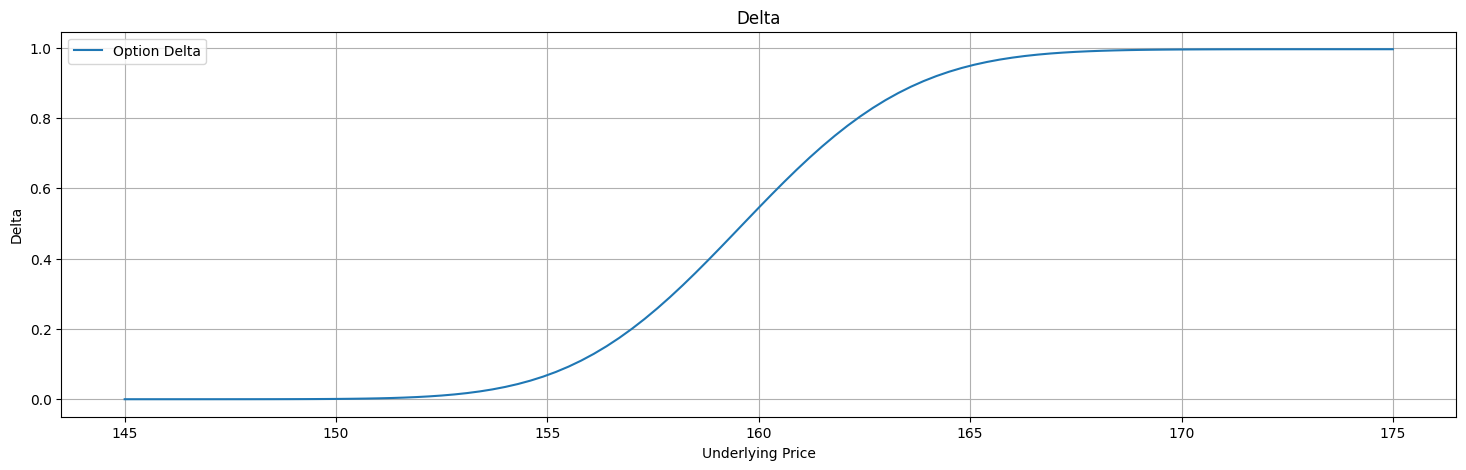

In [47]:
ticker_symbol = 'AAPL'
S = 160 
K = 165 
T = 1

# Using the function to calculate Greeks data (Volatility, Dividend Yield, RF Interest rate)
sigma, q, r = greeks_components(ticker=ticker_symbol, period='1y')

# Using the functions to calculate the values of N_d1 and N_d2
N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=S, div_yield=q, time=T, option_type='call', vol=sigma)

# Compute Delta w.r.t. changes in Underlying price
delta = []
for i in np.linspace(S - 15, S + 15, 101): # We are sweeping across a range of underlying prices from S-15 to S+15, with 101 points in between (inclusive)
  # Using the functions to iterate and recompute Delta for each underlying price
  d = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)[0]
  d = np.exp(-q * T) * d # Calculate value of Delta
  delta.append(d)

# Plot the Delta values w.r.t. Underlying price
plt.figure(figsize=(18,5))
plt.plot(np.linspace(S-15, S+15, 101), delta, label='Option Delta')
plt.title('Delta')
plt.xlabel('Underlying Price')
plt.ylabel('Delta')
plt.legend()
plt.grid()
plt.show()

Let us take this one step further, and see how $\text{Delta Δ}$ w.r.t the underlying price $S$ and time to expiry $T$

In [48]:
# Get the values of Delta w.r.t. changes in the Underlying price and Time to expiry
deltaUT = []
for i in np.linspace(S - 15, S + 15, 101): # We are sweeping across a range of underlying prices from S-15 to S+15, with 101 points in between (inclusive)
  # Iterating to get values of Delta w.r.t. the Underlying price
  deltaT = []
  for j in np.linspace(0.000001, 5, 101): 
    # Iterating to get values of Delta w.r.t. the Time to expiry
    d = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)[0]
    d = np.exp(-q * T) * d # Calculate value of Delta
    deltaT.append(d)
  deltaUT.append(deltaT)
  
# Create a DataFrame for Delta w.r.t. changes in the Underlying price and Time to expiry
df_delta = pd.DataFrame(deltaUT, index=np.linspace(S - 15, S + 15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot for the Option's Delta surface

In [49]:
# Creating the Option Delta surface
fig = go.Figure(data=[go.Surface(z=df_delta.values)])
fig.update_layout(
  title='3D plot of an Option Delta', 
  autosize=False, 
  width=1300, 
  height=600, 
  margin=dict(l=50, r=50, b=65, t=90), 
  scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Delta')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))
fig.show()

#### 4.2 Gamma Γ

$\text{Gamma Γ}$ is one of the key **Option Greeks**. It measures **how fast an option's Delta changes** when the underlying asset price moves.
- Delta ≈ "speed" of the option price relative to the stock  
- Gamma ≈ **"acceleration"** of that delta (second derivative)

In mathematical terms (Black–Scholes framework):

$$
\Gamma = \frac{\partial \Delta}{\partial S} = \frac{\partial^2 C}{\partial S^2} \quad \text{or} \quad \frac{\partial^2 P}{\partial S^2}
$$

where  
- $C$ = call price, $P$ = put price  
- $S$ = underlying asset price  
- $\Delta$ = first derivative (delta)

**Why traders care about Gamma?**

- Gamma tells you **how much your directional exposure (delta) will change** with a $1 move in the stock.
- High gamma → delta changes rapidly → your position becomes more/less directional very quickly.
- Think of it like driving:  
  - Delta = your current speed  
  - Gamma = how quickly your speed is increasing (or decreasing)

Gamma is highest for at-the-money options and decreases as the option moves further in or out of the money. When an option is deep in or out of the money, the gamma value will be close to zero. Gamma is an important greek to consider when trading options as it can help determine the optimal strike price to trade and how to hedge the position against price movements in the underlying asset.

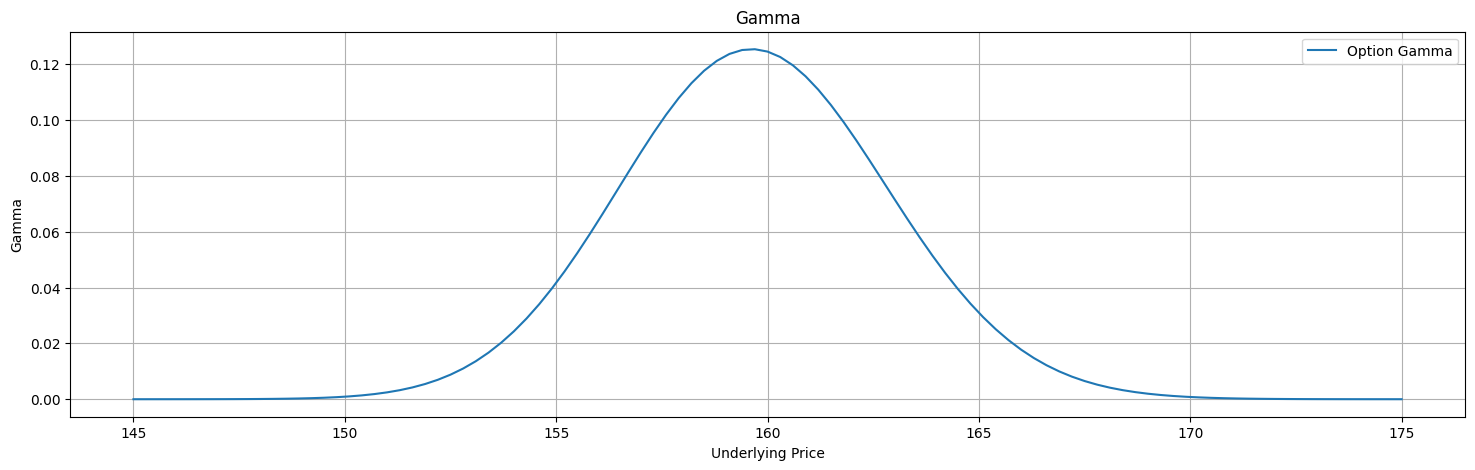

In [51]:
# Get the values of Gamma w.r.t. changes in Underlying price
gamma = []
for i in np.linspace(S-15, S+15, 101): # Generating a range of underlying prices from S-15 to S+15, with 101 points in between (inclusive)
  # Using the functions to iterate and get the value of Gamma for each underlying price
  g = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)[2] # Get the value of d1 for each underlying price
  g = np.exp(-q * T) * np.exp(-g ** 2/2) / (S * sigma * np.sqrt(2 * np.pi * T)) # Calculate value of Gamma
  gamma.append(g)

# Plot the Gamma values w.r.t. Underlying price
plt.figure(figsize=(18,5))
plt.plot(np.linspace(S-15, S+15, 101), gamma, label='Option Gamma')
plt.title('Gamma')
plt.xlabel('Underlying Price')
plt.ylabel('Gamma')
plt.legend()
plt.grid();

 Get the values of Gamma w.r.t. changes in the Underlying price and Time to expiry

In [52]:
gammaUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Gamma w.r.t. the Underlying price
  gammaT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of Gamma w.r.t. the Time to expiry
    g = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)[2]
    g = np.exp(-q*T) * np.exp(-g**2/2) / (S*sigma*np.sqrt(2*np.pi*T)) # Calculate value of Delta
    gammaT.append(g)
  gammaUT.append(gammaT) # Append the list to the gammaT to create a DataFrame

# Create a DataFrame for Gamma w.r.t. changes in the Underlying price and Time to expiry
df_gamma = pd.DataFrame(gammaUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot of the Option's Gamma surface

In [54]:
# Creating the Option Gamma surface
fig = go.Figure(data=[go.Surface(z=df_gamma.values)])
fig.update_layout(
  title='3D plot of an Option Gamma', 
  autosize=False, 
  width=1300, 
  height=600, 
  margin=dict(l=50, r=50, b=65, t=90), scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Gamma')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))  
# Show the plot
fig.show()

#### 4.3 Theta Θ

It measures **how much an option's value decreases** each day purely due to the passage of time — assuming all other factors (stock price, volatility, interest rates) stay constant. This daily erosion is called **time decay**.

In mathematical terms (Black–Scholes framework):

$$
\Theta = -\frac{\partial C}{\partial t} \quad \text{or} \quad -\frac{\partial P}{\partial t}
$$

Theta is expressed in **dollars per day** (or currency units per day) per option contract. The negative sign represents value declining as time passes.

**Why traders care about Theta**

- Options are **wasting assets** — they lose extrinsic (time) value every single day, even if the stock doesn't move.
- **Long options** (buyers) fight against theta — it's working against you.
- **Short options** (sellers) benefit from theta — time decay is your friend; premium slowly decays into your pocket.


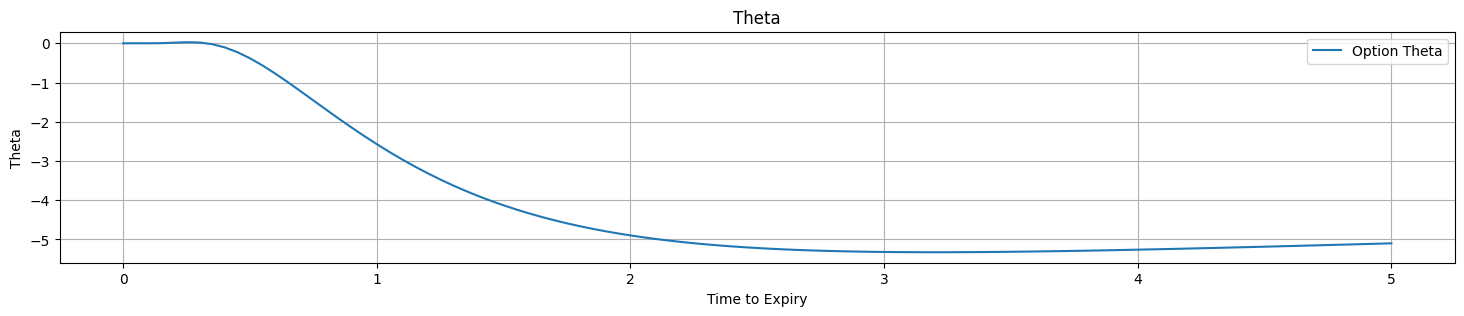

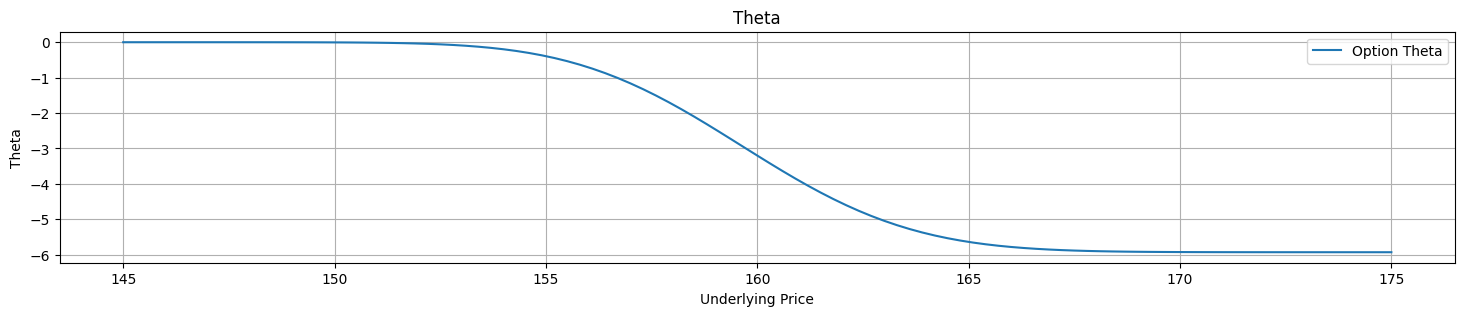

In [58]:
# Get the values of Theta w.r.t. changes in Time to Expiry
theta = []
for i in np.linspace(0.000001, 5, 101):
  # Using the functions to iterate and get the value of Theta for time step
  N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=S, div_yield=q, time=i, option_type='call', vol=sigma)
  n_d1 = norm.pdf(d1) # Calculate the standard normal probability density function for d1
  # Calculate value of Theta
  t = ((S * sigma * n_d1) / (2 * np.sqrt(i))) - (r * K * np.exp(-r * i) * N_d2)
  theta.append(t)

# Plot the Theta values w.r.t. Time to Expiry
plt.figure(figsize=(18, 3))
plt.plot(np.linspace(0.000001, 5, 101), theta, label='Option Theta')
plt.title('Theta')
plt.xlabel('Time to Expiry')
plt.ylabel('Theta')
plt.legend()
plt.grid();

# Get the values of Theta w.r.t. changes in Underlying price
theta = []
for i in np.linspace(S-15, S+15, 101):
    # Using the functions to iterate and get the value of Theta for each underlying price
    N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i,
                div_yield=q, time=T, option_type='call', vol=sigma)
    n_d1 = norm.pdf(d1) # Calculate normal probability density function for d1
    # Calculate value of Theta
    t = -(1/365) * ((i*sigma*n_d1)/(2*np.sqrt(T))) - (r*K*np.exp(-r*T)*N_d2)
    theta.append(t)

# Plot the Theta values w.r.t. Underlying price
plt.figure(figsize=(18, 3))
plt.plot(np.linspace(S-15, S+15, 101), theta, label='Option Theta')
plt.title('Theta')
plt.xlabel('Underlying Price')
plt.ylabel('Theta')
plt.legend()
plt.grid();


Get the values of Theta w.r.t. changes in the Underlying price and Time to expiry

In [59]:
# Get the values of Theta w.r.t. changes in the Underlying price and Time to expiry
thetaUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Theta w.r.t. the Underlying price
  thetaT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of Theta w.r.t. the Time to expiry
    N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)
    n_d1 = norm.pdf(d1) # Calculate normal probability density function for d1
    # Calculate value of Theta
    t = -(1/365) * ((i*sigma*n_d1)/(2*np.sqrt(j))) - (r*K*np.exp(-r*j)*N_d2)
    thetaT.append(t)
  thetaUT.append(thetaT) # Append the list to the thetaT to create a DataFrame
  
# Create a DataFrame for Theta w.r.t. changes in the Underlying price and Time to expiry
df_theta = pd.DataFrame(thetaUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot for the Option's Theta surface

In [60]:
# Creating the Option theta surface
fig = go.Figure(data=[go.Surface(z=df_theta.values)])
fig.update_layout(
  title='3D plot of an Option Theta', 
  autosize=False, 
  width=1300, 
  height=600, 
  margin=dict(l=50, r=50, b=65, t=90), scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Theta')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))  
# Show the plot
fig.show()

#### 4.4 Rho (Ρ) 

Rho (Ρ) measures **how sensitive an option's price is to changes in the risk-free interest rate** (typically the yield on short-term U.S. Treasury bills). In mathematical terms (Black–Scholes framework):

$$
\rho = \frac{\partial C}{\partial r} \quad \text{or} \quad \frac{\partial P}{\partial r}
$$

where  
- $C$ = call price, $P$ = put price  
- $r$ = risk-free interest rate  
- Rho is usually expressed as the change in option price for a **1 percentage point** (0.01 or 1%) change in rates.

Rho tells you how much the option premium is expected to gain or lose if rates shift by 1% (all else equal).

**Why traders care about Rho**

- Higher interest rates make it more expensive to hold cash → calls become more attractive (you delay paying for the stock).  
- Higher rates make puts less valuable (the right to sell later is worth less when money today earns more).  
- Think of rho as the **"carry cost" adjustment** in options pricing — interest rates affect the forward price of the underlying.

Rho is often called the **"forgotten Greek"** because:  
- Interest rates usually move slowly and in small increments.  
- It's impact is small compared to delta, gamma, theta, or vega for most short-term equity options.

But rho becomes **more important** in:  
- Long-dated options (LEAPs, 1+ year expirations)  
- High-interest-rate environments  
- Options on high-priced underlyings or indexes  
- Rate-sensitive strategies (e.g., during Fed policy shifts)

For call options, rho is positive, which means that an increase in the risk-free interest rate will increase the value of the call option. For put options, rho is negative, which means that an increase in the risk-free interest rate will decrease the value of the put option.

Rho is an important factor to consider when interest rates are expected to change, especially in long-term options. In general, options with longer expiration dates have higher rho values than those with shorter expiration dates.

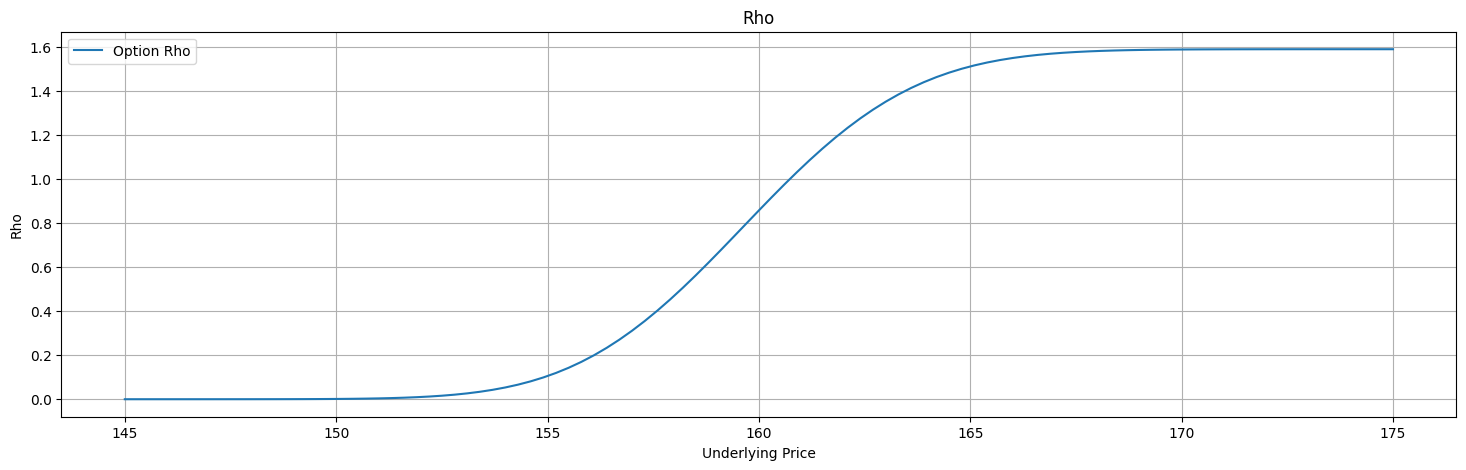

In [ ]:
# Get the values of Rho w.r.t. changes in Underlying price
rho = []
for i in np.linspace(S-15, S+15, 101):
  # Using the functions to iterate and get the value of Rho for each underlying price
  N_d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)[1]
  # Calculate value of rho
  rh = K * T * np.exp(-r * T) * N_d2 / 100
  rho.append(rh)
    
# Plot the rho values w.r.t. Underlying price
plt.figure(figsize=(18, 5))
plt.plot(np.linspace(S-15, S+15, 101), rho, label='Option Rho')
plt.title('Rho')
plt.xlabel('Underlying Price')
plt.ylabel('Rho')
plt.legend()
plt.grid();

Get the values of Rho w.r.t. changes in the Underlying price and Time to expiry

In [63]:
# Get the values of Rho w.r.t. changes in the Underlying price and Time to expiry
rhoUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Rho w.r.t. the Underlying price
  rhoT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of Rho w.r.t. the Time to expiry
    N_d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)[1]
    # Calculate value of rho
    rh = K * T * np.exp(-r * T) * N_d2 / 100
    rhoT.append(rh)
  rhoUT.append(rhoT) # Append the list to the rhoT to create a DataFrame

# Create a DataFrame for Rho w.r.t. changes in the Underlying price and Time to expiry
df_rho = pd.DataFrame(rhoUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot for the Option's Rho surface

In [65]:
# Creating the Option rho surface
fig = go.Figure(data=[go.Surface(z=df_rho.values)])
fig.update_layout(
  title='3D plot of an Option Rho', 
  autosize=False, 
  width=1300, 
  height=600,
  margin=dict(l=50, r=50, b=65, t=90), scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Rho')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))  
# Show the plot
fig.show()

#### 4.5 Vega ν

It measures **how much an option's price changes** when the **implied volatility** (IV) of the underlying asset changes by **1 percentage point** (e.g., from 25% to 26%). In mathematical terms (Black–Scholes framework):

$$
\nu = \frac{\partial C}{\partial \sigma} = \frac{\partial P}{\partial \sigma}
$$

where  
- $C$ = call price, $P$ = put price  
- $\sigma$ = implied volatility (annualized)  
- Vega is identical for calls and puts with the same strike and expiration.

Vega is usually expressed as the dollar change in option premium for a **1%** change in IV (so divide the raw derivative by 100 if needed).

**Why traders care about Vega**

- Options price **extrinsic value** (time value) largely from expected volatility — higher IV = higher chance of big moves = more valuable options.  
- Vega tells you **how much premium you're paying (or collecting) for volatility exposure**.  
- Long options → **positive vega** — you benefit from volatility rising (IV expansion).  
- Short options → **negative vega** — you benefit from volatility falling (IV contraction / crush).

Think of vega like **buying insurance on market fear**:  
- Long vega = you're long "fear" → profit when markets get choppy or uncertain.  
- Short vega = you're short "fear" → profit when things calm down (common in premium-selling strategies).

Vega is typically expressed as a positive number, and the higher the vega, the more sensitive the option's price is to changes in implied volatility. Vega is an important factor in option pricing, as implied volatility is one of the key components in the Black-Scholes model. Options with higher implied volatility have higher premiums, all else being equal, because they are more likely to experience larger price movements. Vega helps traders to manage their exposure to volatility risk, as well as to identify potentially undervalued or overvalued options.

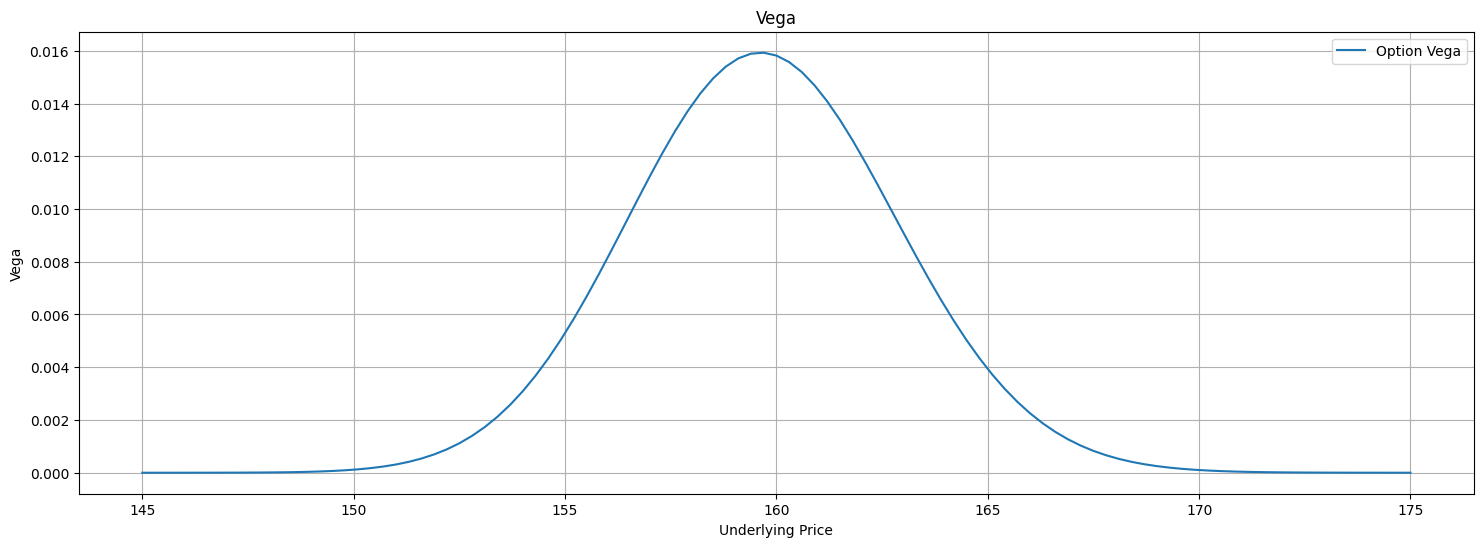

In [66]:
# Get the values of Vega w.r.t. changes in Underlying price
vega = []
for i in np.linspace(S-15, S+15, 101):
  # Using the functions to iterate and get the value of Vega for each underlying price
  d1 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)[2]
  v = S * np.exp(-q * T) * np.exp(-d1 ** 2/2) * np.sqrt(T) / (100 * 100) # Calculate value of Vega
  vega.append(v)
    
# Plot the vega values w.r.t. Underlying price
plt.figure(figsize=(18, 6))
plt.plot(np.linspace(S-15, S+15, 101), vega, label='Option Vega')
plt.title('Vega')
plt.xlabel('Underlying Price')
plt.ylabel('Vega')
plt.legend()
plt.grid();

Get the values of Vega w.r.t. changes in the Underlying price and Time to expiry

In [ ]:
vegaUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Vega w.r.t. the Underlying price
  vegaT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of Vega w.r.t. the Time to expiry
    d1 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)[2]
    v = S*np.exp(-q*T)*np.exp(-d1**2/2)*np.sqrt(T)/(100*100) # Calculate value of Vega
    vegaT.append(v)
  vegaUT.append(vegaT) # Append the list to the vegaT to create a DataFrame
  
# Create a DataFrame for Vega w.r.t. changes in the Underlying price and Time to expiry
df_vega = pd.DataFrame(vegaUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot for the Option's Vega surface

In [68]:
# Creating the Option Vega surface
fig = go.Figure(data=[go.Surface(z=df_vega.values)])
fig.update_layout(
  title='3D plot of an Option Vega', 
  autosize=False, 
  width=1300, 
  height=600,
  margin=dict(l=50, r=50, b=65, t=90), scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Vega')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))
fig.show()

#### Higher Order Greeks

#### 4.6 Speed

**Speed** is a **third-order Greek** — it goes one level deeper than the standard first-order Greeks (Delta, Theta, Vega, Rho) and second-order Gamma. It measures **how fast an option's Gamma changes** when the underlying asset price moves by $1 (all else equal). In mathematical terms (Black–Scholes framework):

$$
\text{Speed} = \frac{\partial \Gamma}{\partial S} = \frac{\partial^3 C}{\partial S^3} \quad \text{or} \quad \frac{\partial^3 P}{\partial S^3}
$$

- Also called **DgammaDspot** or **"the gamma of the gamma"**  
- It's the **third derivative** of the option price with respect to the underlying price S.

Think of the physics analogy chain:

- Delta ≈ **speed** (how fast option price changes with stock)  
- Gamma ≈ **acceleration** (how fast delta changes with stock)  
- Speed ≈ **jerk** (how fast acceleration/gamma changes with stock)

Speed tells you **how stable or unstable your gamma (convexity) is** as the stock moves — crucial when gamma is high and changing rapidly.

**Why traders care about Speed**

- High (absolute) speed means gamma can spike or collapse quickly with small stock moves → your convexity/hedging needs change fast.  
- Long gamma positions (long options) usually have **positive speed** when OTM → gamma increases as stock moves toward ATM.  
- Near ATM or deep ITM → speed can flip signs or become very small.  
- Speed is most relevant for:  
  - Gamma scalpers  
  - Short-dated / 0DTE trading (gamma explodes near expiry)  
  - Large books / market makers who delta-hedge frequently  
  - Positions where gamma is already high and stock is volatile

Speed is **rarely the dominant risk** for retail traders — but it becomes noticeable in fast-moving markets or when managing gamma-heavy positions.


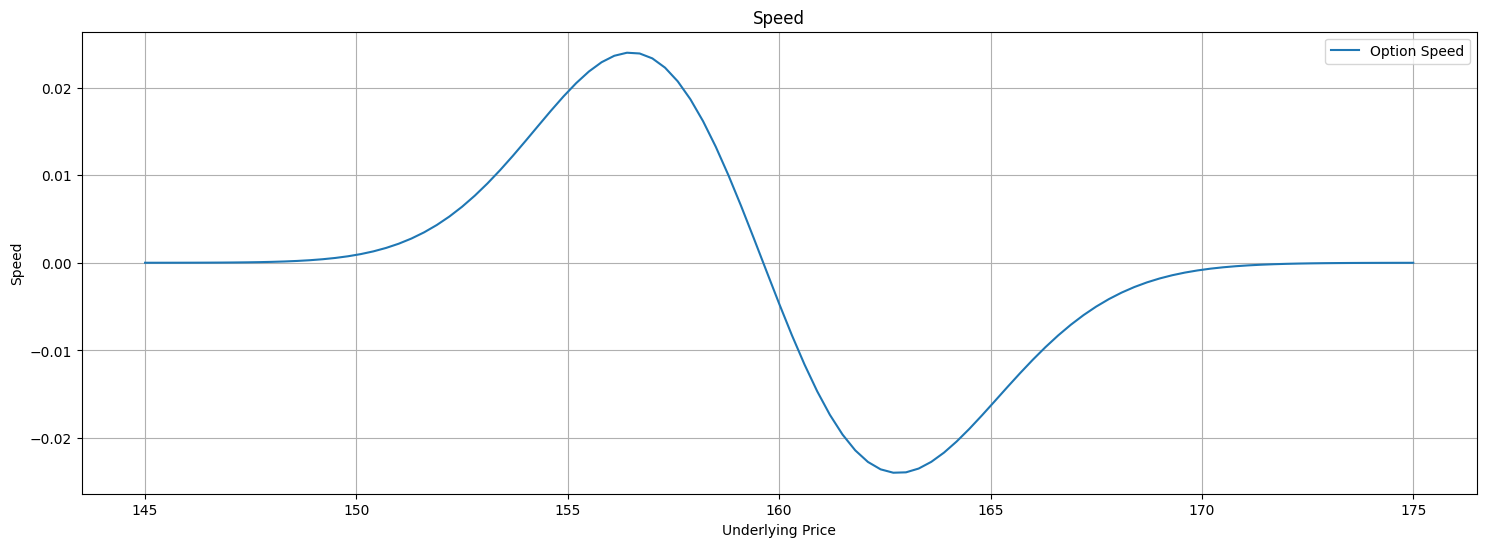

In [69]:
# Get the values of Speed w.r.t. changes in Underlying price
speed = []
for i in np.linspace(S-15, S+15, 101):
  # Using the functions to iterate and get the value of Speed for each underlying price
  d1 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)[2]
  g = np.exp(-q*T) * np.exp(-d1**2/2) / (S*sigma*np.sqrt(2*np.pi*T)) # Calculate value of Gamma
  s = -g * d1 / (S * sigma * np.sqrt(T)) # Calculate value of Speed
  speed.append(s)
    
# Plot the Speed values w.r.t. Underlying price
plt.figure(figsize=(18,6))
plt.plot(np.linspace(S-15, S+15, 101), speed, label='Option Speed')
plt.title('Speed')
plt.xlabel('Underlying Price')
plt.ylabel('Speed')
plt.legend()
plt.grid();

Get the values of Speed w.r.t. changes in the Underlying price and Time to expiry

In [70]:
speedUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Speed w.r.t. the Underlying price
  speedT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of Speed w.r.t. the Time to expiry
    d1 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)[2]
    g = np.exp(-q*T) * np.exp(-d1**2/2) / (S*sigma*np.sqrt(2*np.pi*T)) # Calculate value of Gamma
    s = -g*d1/(S*sigma*np.sqrt(T)) # Calculate value of Speed
    speedT.append(s)
  speedUT.append(speedT) # Append the list to the speedT to create a DataFrame
  
# Create a DataFrame for Speed w.r.t. changes in the Underlying price and Time to expiry
df_speed = pd.DataFrame(speedUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot for the Option's Speed surface

In [71]:
# Creating the Option Speed surface
fig = go.Figure(data=[go.Surface(z=df_speed.values)])
fig.update_layout(
  title='3D plot of an Option Speed', 
  autosize=False, 
  width=1300, 
  height=600,
  margin=dict(l=50, r=50, b=65, t=90), scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Speed')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))
fig.show()

#### 4.7 Vomma

**Vomma** (also called **Volga**, **Vega Convexity**, or **DvegaDvol**) is a **second-order Greek** that measures **how an option's Vega changes** when **implied volatility (IV)** changes. In mathematical terms (Black–Scholes framework):

$$
\text{Vomma} = \frac{\partial \nu}{\partial \sigma} = \frac{\partial^2 C}{\partial \sigma^2} = \frac{\partial^2 P}{\partial \sigma^2}
$$

where  
- $\nu$ = Vega (first-order sensitivity to volatility)  
- $\sigma$ = implied volatility  
- $C$ / $P$ = call / put price  

Vomma quantifies the **convexity of the option price with respect to volatility** — it's the "gamma" but for volatility (hence "Vol-ga").

**Why traders care about Vomma**

- Vega tells you how much the option gains/loses from a 1% IV change.  
- Vomma tells you **how much that Vega itself grows or shrinks** when IV moves.  
- Positive vomma → Vega increases as IV rises → your volatility exposure **accelerates** in your favor (long vol convexity).  
- Negative vomma → Vega decreases as IV rises → convexity works against you.

Think of it like this:  
- Vega ≈ "speed" in volatility space  
- Vomma ≈ **"acceleration"** of that speed — long vomma means your vol bet gets bigger (more vega) the more vol rises.

This is especially powerful in **skewed / smile** regimes or around events where IV can explode.

Vomma is an important Greek because it can help traders manage their vega risk. If a trader has a long vega position, then a positive vomma means that the vega will increase if the implied volatility increases. Conversely, if a trader has a short vega position, then a negative vomma means that the vega will decrease if the implied volatility increases. Therefore, traders can use vomma to determine how much they need to hedge their vega risk in response to changes in implied volatility.

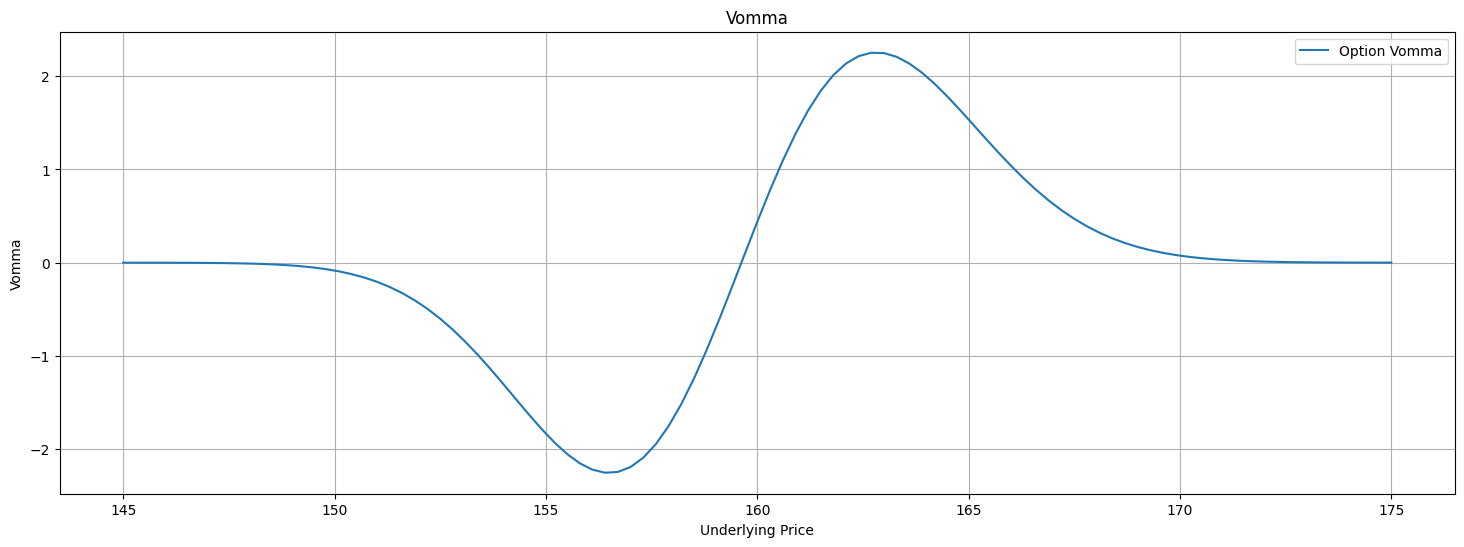

In [72]:
# Get the values of Vomma w.r.t. changes in Underlying price
vomma = []
for i in np.linspace(S-15, S+15, 101):
  # Using the functions to iterate and get the value of Vomma for each underlying price
  d1 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)[2]
  veg = S*np.exp(-q*T)*np.exp(-d1**2/2)*np.sqrt(T)/(100*100) # Calculate value of Vega
  v = veg*d1*d2/sigma
  vomma.append(v)
    
# Plot the vomma values w.r.t. Underlying price
plt.figure(figsize=(18,6))
plt.plot(np.linspace(S-15, S+15, 101), vomma, label='Option Vomma')
plt.title('Vomma')
plt.xlabel('Underlying Price')
plt.ylabel('Vomma')
plt.legend()
plt.grid();

Get the values of Vomma w.r.t. changes in the Underlying price and Time to expiry

In [73]:
vommaUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Vomma w.r.t. the Underlying price
  vommaT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of Vomma w.r.t. the Time to expiry
    d1 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)[2]
    veg = S*np.exp(-q*T)*np.exp(-d1**2/2)*np.sqrt(T)/(100*100) # Calculate value of Vega
    v = veg*d1*d2/sigma
    vommaT.append(v)
  vommaUT.append(vommaT) # Append the list to the vommaT to create a DataFrame
  
# Create a DataFrame for Vomma w.r.t. changes in the Underlying price and Time to expiry
df_vomma = pd.DataFrame(vommaUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot for the Option's Vomma surface

In [74]:
# Creating the Option Vomma surface
fig = go.Figure(data=[go.Surface(z=df_vomma.values)])
fig.update_layout(
  title='3D plot of an Option vomma', 
  autosize=False, 
  width=1300, 
  height=600,
  margin=dict(l=50, r=50, b=65, t=90),scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Vomma')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))
fig.show()

#### 4.8 Charm

**Charm** (also called **Delta Decay**, **Delta Bleed**, or **DdeltaDtime**) is a **second-order Greek** that measures **how an option's Delta changes** with the **passage of one day** (or small change in time to expiration), assuming all other factors remain constant. In mathematical terms (Black–Scholes framework):

$$
\text{Charm} = \frac{\partial \Delta}{\partial t} = \frac{\partial^2 C}{\partial S \partial t} = \frac{\partial \Theta}{\partial S}
$$

where  
- $\Delta$ = Delta  
- $t$ = time to expiration  
- $C$ = call price (same for puts via put-call parity effects)  
- $\Theta$ = Theta  
- $S$ = underlying price  

Charm is the mixed partial derivative — it bridges **delta** (price sensitivity) and **theta** (time decay). Thanks to Schwarz's theorem (mixed partials commute), it's also the sensitivity of theta to changes in the underlying price.

**Why traders care about Charm**

- Delta isn't static over time — as expiration approaches, deltas "decay" or "bleed" toward 0 (OTM) or ±1 (ITM).  
- Charm tells you **how fast that delta is shifting purely from time passing**.  
- Positive charm → delta increases (becomes more positive) as time passes → good for long calls / short puts in certain regimes.  
- Negative charm → delta decreases (becomes less positive or more negative) → common in OTM calls / ITM puts.  

Think of charm as **"delta's personal time decay"**: while theta erodes the option's extrinsic value, charm erodes (or builds) your directional exposure over each day.

A positive charm indicates that the delta of a call option increases as the time to expiration decreases, while the delta of a put option decreases as the time to expiration decreases. A negative charm indicates the opposite. The charm is an important greek to consider when trading options with short expirations, as the effect of time decay on the option delta can be significant. Traders can use charm to adjust their positions as the time to expiration changes, helping them to manage risk and maximize profits.


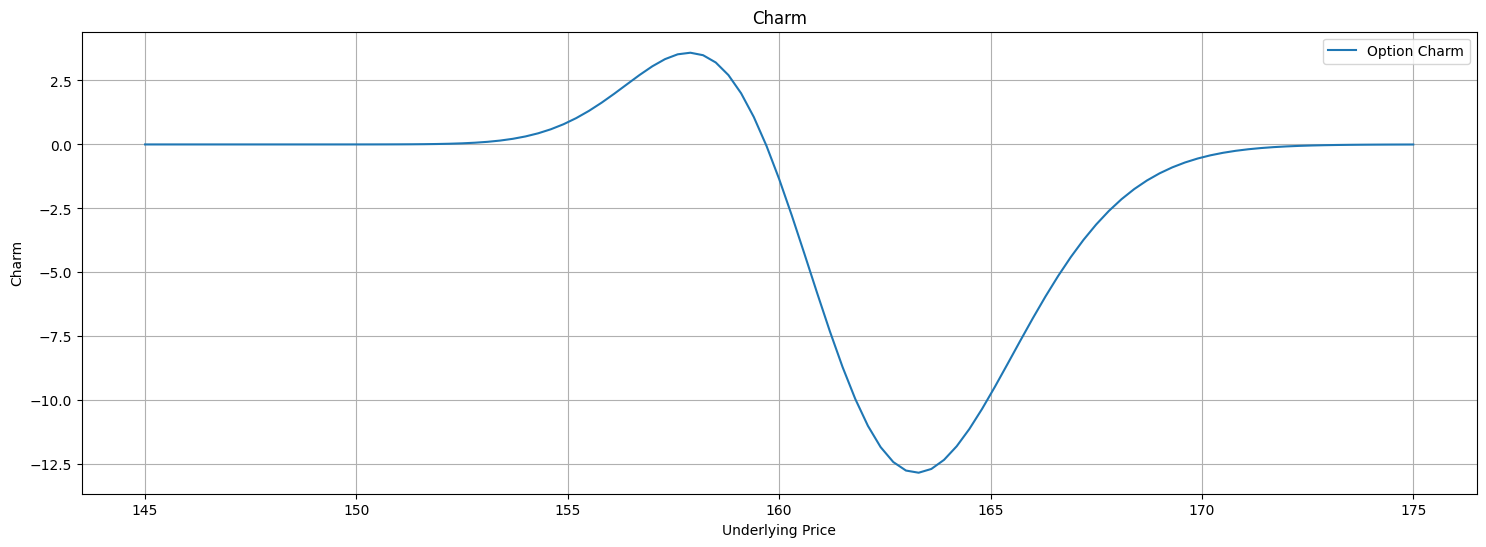

In [75]:
# Get the values of Charm w.r.t. changes in Underlying price
charm = []
for i in np.linspace(S-15, S+15, 101):
  # Using the functions to iterate and get the value of Charm for each underlying price
  N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)
  c = -np.exp(-q*T) * (N_d1*d2*np.exp(-d1**2/2))/(2*T*sigma*np.sqrt(T)) # Calculate the value of Charm
  charm.append(c)
    
# Plot the Charm values w.r.t. Underlying price
plt.figure(figsize=(18, 6))
plt.plot(np.linspace(S-15, S+15, 101), charm, label='Option Charm')
plt.title('Charm')
plt.xlabel('Underlying Price')
plt.ylabel('Charm')
plt.legend()
plt.grid();

Get the values of Charm w.r.t. changes in the Underlying price and Time to expiry

In [76]:
charmUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Charm w.r.t. the Underlying price
  charmT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of charm w.r.t. the Time to expiry
    N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)
    # Calculate the value of Charm
    c = -np.exp(-q*T) * (N_d1*d2*np.exp(-d1**2/2))/(2*T*sigma*np.sqrt(T))
    charmT.append(c)
  charmUT.append(charmT) # Append the list to the charmT to create a DataFrame
  
# Create a DataFrame for Charm w.r.t. changes in the Underlying price and Time to expiry
df_charm = pd.DataFrame(charmUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Creat a dynamic 3D plot for the Option's Charm surface

In [77]:
# Creating the Option Charm surface
fig = go.Figure(data=[go.Surface(z=df_charm.values)])
fig.update_layout(
  title='3D plot of an Option Charm', 
  autosize=False, 
  width=1300, 
  height=600,
  margin=dict(l=50, r=50, b=65, t=90), scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Charm')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))
fig.show()

#### 4.9 Vanna

**Vanna** is a **second-order cross Greek** that measures **how an option's Delta changes** with respect to **changes in implied volatility** (or equivalently, how **Vega** changes with respect to changes in the underlying price). In mathematical terms (Black–Scholes framework):

$$
\text{Vanna} = \frac{\partial \Delta}{\partial \sigma} = \frac{\partial \nu}{\partial S}
$$

where  
- $\Delta$ = Delta  
- $\nu$ (or Vega) = first-order volatility sensitivity  
- $\sigma$ = implied volatility  
- $S$ = underlying asset price  

Vanna captures the **interaction** between directional exposure (delta) and volatility exposure (vega) — it's the "cross-sensitivity" between spot price and volatility.

**Why traders care about Vanna**

- If volatility rises, does your delta become more positive (bullish) or more negative? Vanna tells you.  
- Positive vanna → rising IV increases delta (option becomes more sensitive to upside moves).  
- Negative vanna → rising IV decreases delta (option becomes less directional or flips bias).  

Think of vanna as **"volatility tilting your delta"**:  
- In equity markets (downward skew), OTM puts often have positive vanna → vol spike makes delta more negative (stronger hedge).  
- ATM options have near-zero vanna → delta stays stable with vol changes.  

Vanna drives **"volatility flows"** and dealer hedging behavior — especially important in pinning, squeezes, or post-event vol crush/expansion.

Vanna is an important risk measure for options traders because it helps them manage their exposure to changes in implied volatility. For example, if a trader is long an option and has a positive Vanna, they may want to adjust their position if they expect a decrease in implied volatility.

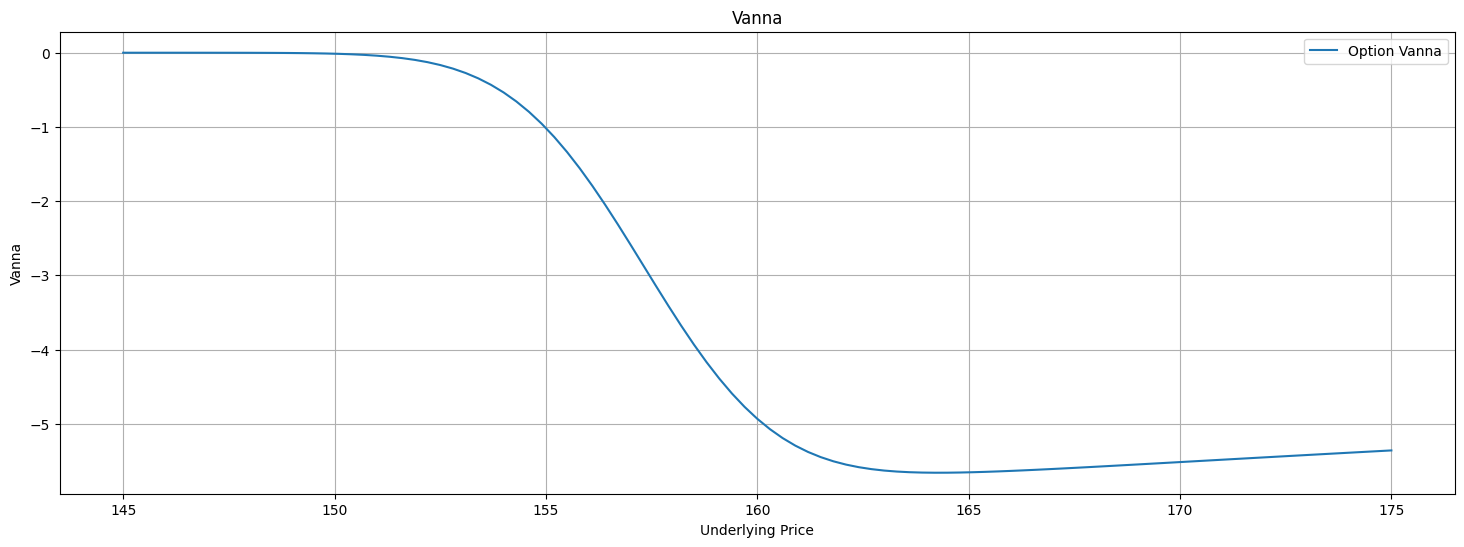

In [78]:
# Get the values of Vanna w.r.t. changes in Underlying price
vanna = []
for i in np.linspace(S-15, S+15, 101):
  # Using the functions to iterate and get the value of Vanna for each underlying price
  N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=T, option_type='call', vol=sigma)
  v = -(np.exp(-N_d1**2/N_d2)*N_d2)/(i*(sigma**2)*T) # Calculate the value of Vanna
  vanna.append(v)
    
# Plot the Vanna values w.r.t. Underlying price
plt.figure(figsize=(18,6))
plt.plot(np.linspace(S-15, S+15, 101), vanna, label='Option Vanna')
plt.title('Vanna')
plt.xlabel('Underlying Price')
plt.ylabel('Vanna')
plt.legend()
plt.grid();

Get the values of Vanna w.r.t. changes in the Underlying price and Time to expiry

In [79]:
vannaUT = []
for i in np.linspace(S-15, S+15, 101):
  # Iterating to get values of Vanna w.r.t. the Underlying price
  vannaT = []
  for j in np.linspace(0.000001, 5, 101):
    # Iterating to get values of Vanna w.r.t. the Time to expiry
    N_d1, N_d2, d1, d2 = bse_delta(ex_price=K, int_rate=r, cur_price=i, div_yield=q, time=j, option_type='call', vol=sigma)
    if (N_d1 == 0) or (N_d2 == 0):
      v = 0
    else:
      v = -(np.exp(-N_d1**2/N_d2)*N_d2)/(i*(sigma**2)*T) # Calculate the value of Vanna
    vannaT.append(v)
  vannaUT.append(vannaT) # Append the list to the vannaT to create a DataFrame
  
# Create a DataFrame for Vanna w.r.t. changes in the Underlying price and Time to expiry
df_vanna = pd.DataFrame(vannaUT, index=np.linspace(S-15, S+15, 101), columns=np.linspace(0.000001, 5, 101))

Create a dynamic 3D plot for the Option's Vanna surface

In [80]:
# Creating the Option Vanna surface
fig = go.Figure(data=[go.Surface(z=df_vanna.values)])
fig.update_layout(
  title='3D plot of an Option Vanna', 
  autosize=False, 
  width=1300, 
  height=600,
  margin=dict(l=50, r=50, b=65, t=90), scene=dict(xaxis_title='Time', yaxis_title='Underlying Price', zaxis_title='Option Vanna')
)
fig.update_traces(y=list(np.linspace(S-15, S+15, 101)), x=list(np.linspace(0.000001, 5, 101)))
fig.show()

In [37]:
# 🚀 Dynamic 3D Option Greeks Visualizer + Trading Strategy Dashboard
# !pip install plotly ipywidgets -q

import numpy as np
from scipy.stats import norm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import (interactive, Dropdown, FloatSlider, IntSlider, VBox, HBox, Label, Button)
import ipywidgets as widgets
from IPython.display import display, clear_output

# ===================== BLACK-SCHOLES + ALL GREEKS =====================
def bs_greeks(S, K, T, r, sigma, option_type='call'):
    if T <= 0:
        price = max(S - K, 0) if option_type == 'call' else max(K - S, 0)
        return {'price': price, 'delta': 1 if option_type == 'call' else -1, 
                'gamma': 0, 'theta': 0, 'vega': 0, 'rho': 0}
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        rho = K * T * np.exp(-r*T) * norm.cdf(d2)
    else:  # put
        price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        rho = -K * T * np.exp(-r*T) * norm.cdf(-d2)
    
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T)          # per 1 unit volatility (multiply by 0.01 for 1%)
    theta = - (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) \
            - r * K * np.exp(-r*T) * norm.cdf(d2 if option_type=='call' else -d2) \
            + (0 if option_type=='call' else r * S * np.exp(-r*T) * norm.cdf(-d1))  # rough theta per year
    
    return {
        'price': price,
        'delta': delta,
        'gamma': gamma,
        'theta': theta / 365,      # daily theta
        'vega': vega * 0.01,       # per 1% IV change (standard trader unit)
        'rho': rho * 0.01          # per 1% rate change
    }

# ===================== STRATEGY PAYOFF =====================
def strategy_value(S_range, strategy, K, mult=1):
    if strategy == "Long Call":
        return np.maximum(S_range - K, 0) * mult
    elif strategy == "Long Put":
        return np.maximum(K - S_range, 0) * mult
    elif strategy == "Long Straddle":
        return np.maximum(S_range - K, 0) + np.maximum(K - S_range, 0) * mult
    elif strategy == "Short Straddle":
        return -(np.maximum(S_range - K, 0) + np.maximum(K - S_range, 0)) * mult
    elif strategy == "Long Butterfly":
        return np.maximum(S_range - (K-10), 0) - 2*np.maximum(S_range - K, 0) + np.maximum(S_range - (K+10), 0) * mult
    else:
        return np.maximum(S_range - K, 0) * mult   # fallback

# ===================== CREATE INTERACTIVE DASHBOARD =====================
def create_greeks_dashboard():
    # Widgets
    strategy_dd = Dropdown(options=["Long Call", "Long Put", "Long Straddle", "Short Straddle", "Long Butterfly"],
                           value="Long Straddle", description="Strategy:")
    
    greek_dd = Dropdown(options=["Delta", "Gamma", "Vega", "Theta"], value="Gamma", description="3D Greek:")
    
    S_slider = FloatSlider(value=225, min=100, max=350, step=1, description="Spot S:", continuous_update=False)
    K_slider = FloatSlider(value=225, min=100, max=350, step=5, description="Strike K:")
    T_slider = IntSlider(value=30, min=1, max=365, step=1, description="Days to Exp:")
    sigma_slider = FloatSlider(value=0.25, min=0.05, max=1.0, step=0.01, description="IV (σ):")
    r_slider = FloatSlider(value=0.05, min=0.0, max=0.10, step=0.005, description="Rate r:")
    
    update_btn = Button(description="🔄 Update All", button_style='success')
    
    # Initial Figure
    fig = make_subplots(rows=2, cols=2,
                        specs=[[{'type': 'surface'}, {'type': 'xy'}],
                               [{'type': 'xy'}, {'type': 'domain'}]],
                        subplot_titles=("3D Greek Surface", "Strategy P&L vs Spot",
                                        "Position Greeks (Current)", "Live Summary"))
    
    fig.update_layout(height=900, width=1400, title_text="📊 Dynamic Option Greeks 3D Visualizer + Strategy Dashboard (March 2026)",
                      showlegend=True)
    
    # Placeholder traces
    fig.add_trace(go.Surface(z=np.zeros((50,50)), colorscale="Viridis", showscale=True, name="Greek"), row=1, col=1)
    fig.add_trace(go.Scatter(x=[0], y=[0], mode='lines', name="Strategy P&L", line=dict(width=3)), row=1, col=2)
    fig.add_trace(go.Scatter(x=[225], y=[0], mode='markers+text', name="Current Spot", marker=dict(size=12, color="red")), row=1, col=2)
    
    fig.add_trace(go.Bar(x=["Delta","Gamma","Vega","Theta"], y=[0.5,0.05,0.22,-0.08], name="Greeks"), row=2, col=1)
    
    fig_widget = go.FigureWidget(fig)
    
    # Update Function
    def update_dashboard(S=225, K=225, T_days=30, sigma=0.25, r=0.05, strategy="Long Straddle", greek="Gamma"):
        T = T_days / 365.0
        S_range = np.linspace(max(50, K-80), K+80, 100)
        
        # 3D Surface: Greek over Spot vs Time
        S_grid = np.linspace(100, 350, 40)
        T_grid = np.linspace(0.01, 1.0, 30)
        S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)
        
        if greek == "Delta":
            Z = np.vectorize(lambda s,t: bs_greeks(s, K, t, r, sigma, 'call' if strategy in ["Long Call","Long Straddle","Long Butterfly"] else 'put')['delta'])(S_mesh, T_mesh)
            colorscale = "RdBu"
        elif greek == "Gamma":
            Z = np.vectorize(lambda s,t: bs_greeks(s, K, t, r, sigma)['gamma'])(S_mesh, T_mesh)
            colorscale = "Plasma"
        elif greek == "Vega":
            Z = np.vectorize(lambda s,t: bs_greeks(s, K, t, r, sigma)['vega'])(S_mesh, T_mesh)
            colorscale = "Viridis"
        else:  # Theta
            Z = np.vectorize(lambda s,t: bs_greeks(s, K, t, r, sigma)['theta'])(S_mesh, T_mesh)
            colorscale = "RdYlBu_r"
        
        with fig_widget.batch_update():
            fig_widget.data[0].z = Z
            fig_widget.data[0].x = S_grid
            fig_widget.data[0].y = T_grid * 365
            fig_widget.data[0].colorscale = colorscale
            fig_widget.data[0].colorbar.title = f"{greek} Surface"
            
            # Strategy P&L chart
            payoff = strategy_value(S_range, strategy, K)
            fig_widget.data[1].x = S_range
            fig_widget.data[1].y = payoff
            fig_widget.data[2].x = [S]          # current spot marker
            fig_widget.data[2].y = [np.interp(S, S_range, payoff)]
            fig_widget.data[2].text = [f"Spot = ${S:.0f}"]
            
            # Current Greeks bar
            g = bs_greeks(S, K, T, r, sigma) if "Call" in strategy or "Straddle" in strategy else bs_greeks(S, K, T, r, sigma, 'put')
            if "Straddle" in strategy or "Butterfly" in strategy:
                g2 = bs_greeks(S, K, T, r, sigma, 'put') if "Straddle" in strategy else bs_greeks(S, K+10, T, r, sigma)
                g['delta'] += g2.get('delta', 0)
                g['gamma'] += g2.get('gamma', 0)
                g['vega'] += g2.get('vega', 0)
                g['theta'] += g2.get('theta', 0)
            
            fig_widget.data[3].y = [g['delta'], g['gamma'], g['vega'], g['theta']]
            
            # Title update
            fig_widget.layout.title.text = f"🔴 LIVE • Strategy: {strategy} | Spot: ${S:.0f} | IV: {sigma:.0%} | Days: {T_days} | 3D: {greek}"
    
    # Link widgets
    def on_change(_=None):
        update_dashboard(S_slider.value, K_slider.value, T_slider.value, 
                         sigma_slider.value, r_slider.value, 
                         strategy_dd.value, greek_dd.value)
    
    for w in [S_slider, K_slider, T_slider, sigma_slider, r_slider, strategy_dd, greek_dd]:
        w.observe(on_change, names='value')
    
    update_btn.on_click(lambda _: on_change())
    
    # Initial render
    update_dashboard()
    
    # Layout
    controls = HBox([VBox([strategy_dd, greek_dd]), 
                     VBox([S_slider, K_slider, T_slider]), 
                     VBox([sigma_slider, r_slider, update_btn])])
    
    display(VBox([Label("🎛️ Drag sliders or change strategy → everything updates LIVE!", style={'font-weight':'bold'}),
                  controls, fig_widget]))

# ===================== LAUNCH IT =====================
create_greeks_dashboard()

In [38]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import (Dropdown, IntSlider, Play, Button, VBox, HBox, Label)
import ipywidgets as widgets
from IPython.display import display, clear_output

# ===================== SAMPLE HISTORIC DATA (Feb 15 – Mar 20 2026) =====================
dates = pd.date_range("2026-02-15", periods=40, freq="B")  # generate more, then slice
spot_history = [218, 221, 215, 224, 229, 235, 231, 242, 238, 245, 251,
                248, 255, 260, 257, 262, 259, 265, 270, 267, 272, 268,
                275, 280, 277, 282, 285, 281, 288, 292, 290]   # 31 values

df_hist = pd.DataFrame({
    "Date": dates[:len(spot_history)],
    "Close": spot_history
}).set_index("Date")

# ===================== BLACK-SCHOLES GREEKS =====================
def bs_greeks(S, K, T, r=0.045, sigma=0.28, option_type="call"):
    if T <= 0.001:
        price = max(S - K, 0) if option_type == "call" else max(K - S, 0)
        return {"price": price, "delta": 1 if option_type=="call" else -1,
                "gamma": 0, "theta": 0, "vega": 0, "rho": 0}
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
        delta = norm.cdf(d1)
    else:
        price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
    
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T) * 0.01   # per 1% IV
    theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2 if option_type=="call" else -d2)) / 365
    
    return {"price": price, "delta": delta, "gamma": gamma,
            "theta": theta, "vega": vega}

# ===================== PRE-COMPUTE SIMULATION =====================
K_entry = 260.0
initial_T_days = 45
sigma_fixed = 0.28
strategy = "Long Straddle"   # will be controllable

def simulate_strategy(strategy_name):
    results = []
    for i in range(len(df_hist)):
        S = df_hist["Close"].iloc[i]
        T_days = max(initial_T_days - i, 0)
        T = T_days / 365.0
        
        if strategy_name == "Long Call":
            g = bs_greeks(S, K_entry, T, option_type="call")
            pnl = g["price"] - 12.5   # assume entry price $12.5
        elif strategy_name == "Long Put":
            g = bs_greeks(S, K_entry, T, option_type="put")
            pnl = g["price"] - 11.8
        elif strategy_name == "Long Straddle":
            g_call = bs_greeks(S, K_entry, T, option_type="call")
            g_put  = bs_greeks(S, K_entry, T, option_type="put")
            g = {k: g_call[k] + g_put[k] for k in g_call}
            pnl = (g_call["price"] + g_put["price"]) - 24.3   # entry debit
        elif strategy_name == "Short Straddle":
            g_call = bs_greeks(S, K_entry, T, option_type="call")
            g_put  = bs_greeks(S, K_entry, T, option_type="put")
            g = {k: -(g_call[k] + g_put[k]) for k in g_call}
            pnl = 24.3 - (g_call["price"] + g_put["price"])   # credit
        else:  # Delta-Hedged Call
            g = bs_greeks(S, K_entry, T, option_type="call")
            pnl = g["price"] - 12.5 - (g["delta"] * (S - 225))  # simple hedge P&L
        
        results.append({
            "day": i,
            "date": df_hist.index[i],
            "spot": S,
            "T_days": T_days,
            "price": g["price"] if "call" in strategy_name else g.get("price", 0),
            "pnl": pnl,
            "delta": g["delta"],
            "gamma": g["gamma"],
            "vega": g["vega"],
            "theta": g["theta"]
        })
    return pd.DataFrame(results)

# ===================== DASHBOARD =====================
def create_historical_greeks_sim():
    strat_dd = Dropdown(options=["Long Call", "Long Put", "Long Straddle", "Short Straddle", "Delta-Hedged Call"],
                        value="Long Straddle", description="Strategy:")
    
    greek_dd = Dropdown(options=["Delta", "Gamma", "Vega", "Theta"], value="Gamma", description="Track Greek:")
    
    day_slider = IntSlider(value=0, min=0, max=len(df_hist)-1, step=1, description="Simulation Day:")
    play = Play(value=0, min=0, max=len(df_hist)-1, step=1, interval=300, description="▶ Play History")
    
    update_btn = Button(description="▶ Run New Strategy", button_style="success")
    
    fig = make_subplots(rows=3, cols=2,
                        subplot_titles=("📈 Spot + Strategy P&L Evolution",
                                        "3D Greek Surface (Current Day)",
                                        "📉 Selected Greek Over Time",
                                        "All Greeks Stack", "Live Summary", ""),
                        specs=[[{'colspan':2}, None],
                               [{'colspan':1}, {'type':'surface'}],
                               [{'colspan':1}, {'colspan':1}]])
    
    fig.update_layout(height=1100, title_text="🔥 Historical Strategy + Evolving Greeks Simulator • AAPL Mar 2026",
                      template="plotly_dark")
    
    fig_widget = go.FigureWidget(fig)
    
    def update_frame(day):
        strat = strat_dd.value
        sim = simulate_strategy(strat)
        current = sim.iloc[day]
        greeks = ["Delta", "Gamma", "Vega", "Theta"]
        
        with fig_widget.batch_update():
            # Top chart: Spot + P&L
            fig_widget.data[0].x = sim["date"][:day+1]
            fig_widget.data[0].y = sim["spot"][:day+1]
            fig_widget.data[1].x = sim["date"][:day+1]
            fig_widget.data[1].y = sim["pnl"][:day+1]
            
            # 3D Surface (Gamma or Vega surface around current spot & remaining T)
            S_grid = np.linspace(current["spot"]-30, current["spot"]+30, 25)
            K_grid = np.linspace(K_entry-20, K_entry+20, 25)
            Z = np.vectorize(lambda s, k: bs_greeks(s, k, current["T_days"]/365.0)[greek_dd.value.lower()])(S_grid[:,None], K_grid)
            
            fig_widget.data[2].x = S_grid
            fig_widget.data[2].y = K_grid
            fig_widget.data[2].z = Z
            
            # Greek time series (bold line)
            fig_widget.data[3].x = sim["date"][:day+1]
            fig_widget.data[3].y = sim[greek_dd.value.lower()][:day+1]
            
            # All Greeks stack
            for i, g in enumerate(greeks):
                fig_widget.data[4+i].y = sim[g.lower()][:day+1]
            
            # Markers & title
            fig_widget.layout.title.text = f"Day {day} • {current['date'].date()} • Spot ${current['spot']:.0f} • {strat} • {greek_dd.value} = {current[greek_dd.value.lower()]:.4f}"
            
            # Summary box
            fig_widget.data[-1].text = [f"""P&L: <b>${current['pnl']:.2f}</b><br>
                                           Delta: {current['delta']:.3f}<br>
                                           Gamma: {current['gamma']:.4f}<br>
                                           Vega : {current['vega']:.3f}<br>
                                           Theta/day: {current['theta']:.3f}"""]
            
            fig_widget.add_annotation(
              text=f"""<b>Live Summary – Day {day}</b><br>
                        Spot: ${current['spot']:.2f}<br>
                        P&L: ${current['pnl']:.2f}<br>
                        Delta: {current['delta']:.3f}<br>
                        Gamma: {current['gamma']:.4f}<br>
                        Vega:  {current['vega']:.3f}<br>
                        Theta (daily): {current['theta']:.3f}""",
              xref="paper", yref="paper",
              x=0.02, y=0.12,          # bottom left-ish
              showarrow=False,
              align="left",
              font=dict(size=13),
              bgcolor="rgba(0,0,0,0.6)",
              bordercolor="white",
              borderwidth=1,
              borderpad=6
          )
    
    # Initial traces
    sim0 = simulate_strategy("Long Straddle")
    fig_widget.add_trace(go.Scatter(name="Spot", line=dict(color="cyan")), row=1, col=1)
    fig_widget.add_trace(go.Scatter(name="P&L", line=dict(color="gold", dash="dot")), row=1, col=1)
    
    fig_widget.add_trace(go.Surface(colorscale="Plasma", showscale=True, name="3D Greek"), row=2, col=2)
    
    fig_widget.add_trace(go.Scatter(name=f"Selected {greek_dd.value}", line=dict(width=4, color="red")), row=3, col=1)
    
    for g in ["Delta", "Gamma", "Vega", "Theta"]:
        fig_widget.add_trace(go.Scatter(name=g, mode="lines"), row=3, col=2)
    
    #fig_widget.add_trace(go.Table(header=dict(values=["Live Summary"]), cells=dict(values=[[""]])), row=3, col=1)  # placeholder
    
    # Controls linkage
    def on_change(change=None):
        update_frame(day_slider.value)
    
    day_slider.observe(on_change, "value")
    greek_dd.observe(on_change, "value")
    strat_dd.observe(lambda _: update_frame(day_slider.value), "value")
    
    play.observe(lambda c: day_slider.set_trait("value", play.value), "value")
    
    update_btn.on_click(lambda _: [sim := simulate_strategy(strat_dd.value), day_slider.set_trait("max", len(sim)-1), update_frame(0)])
    
    # Initial draw
    update_frame(0)
    
    controls = HBox([strat_dd, greek_dd, day_slider, play, update_btn])
    display(VBox([Label("🎮 Drag slider / press ▶ Play • Change strategy anytime → everything updates!", style={"font-size":"16px", "font-weight":"bold"}),
                  controls, fig_widget]))

# ===================== LAUNCH =====================
create_historical_greeks_sim()